In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

## 1. Data Loading & Alignment

In [2]:
OFFSET = 1_000_000
OPTION_PRODUCTS = ['VEV_4000','VEV_4500','VEV_5000','VEV_5100','VEV_5200',
                   'VEV_5300','VEV_5400','VEV_5500','VEV_6000','VEV_6500']
STRIKES = {p: int(p.split('_')[1]) for p in OPTION_PRODUCTS}
UNDERLYING = 'VELVETFRUIT_EXTRACT'

frames = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'data/prices_round_3_day_{day}.csv', delimiter=';')
    df['day'] = day
    df['global_ts'] = df['timestamp'] + day * OFFSET
    frames.append(df)
raw = pd.concat(frames, ignore_index=True)

print(f"Loaded {len(raw):,} rows across {raw['day'].nunique()} days")
print(f"Products: {sorted(raw['product'].unique())}")

Loaded 360,000 rows across 3 days
Products: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [3]:
# Compute mid price for every product
raw['mid'] = (raw['bid_price_1'] + raw['ask_price_1']) / 2

# Build aligned wide table: one row per timestamp, columns = mid prices
all_products = [UNDERLYING] + OPTION_PRODUCTS
pivot = raw[raw['product'].isin(all_products)].pivot_table(
    index='global_ts', columns='product', values='mid'
).reset_index()

# Also keep bid/ask for the underlying (needed for vol and fill-quality checks)
und = raw[raw['product'] == UNDERLYING][['global_ts','day','timestamp',
                                          'bid_price_1','ask_price_1','mid',
                                          'bid_volume_1','ask_volume_1']].copy()
und.rename(columns={'mid':'S','bid_price_1':'S_bid','ask_price_1':'S_ask'}, inplace=True)

pivot = pivot.merge(und[['global_ts','day','timestamp','S_bid','S_ask',
                          'bid_volume_1','ask_volume_1']], on='global_ts', how='left')
pivot.rename(columns={'VELVETFRUIT_EXTRACT':'S'}, inplace=True)

# Time-to-expiry: fraction of total game remaining
MAX_TS = pivot['global_ts'].max()
pivot['T'] = (MAX_TS - pivot['global_ts']) / MAX_TS   # 1 at open of day 0, 0 at last tick

print(f"Aligned table: {pivot.shape}")
print(f"T range: {pivot['T'].min():.4f} – {pivot['T'].max():.4f}")
pivot.head(3)

Aligned table: (30000, 19)
T range: 0.0000 – 1.0000


,global_ts,S,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500,day,timestamp,S_bid,S_ask,bid_volume_1,ask_volume_1,T
0,0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5,0,0,5247,5253,67,67,1.000000
1,100,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5,0,100,5248,5253,69,23,0.999967
2,200,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5,0,200,5248,5253,20,60,0.999933


## 2. Option Metrics: Intrinsic Value, Time Value, Moneyness

In [4]:
# For each option, compute intrinsic value, time value, and moneyness
metrics = []
for product in OPTION_PRODUCTS:
    K = STRIKES[product]
    sub = pivot[['global_ts','day','timestamp','T','S', product]].dropna(subset=[product,'S']).copy()
    sub.rename(columns={product: 'C'}, inplace=True)
    sub['K']          = K
    sub['product']    = product
    sub['intrinsic']  = np.maximum(sub['S'] - K, 0)
    sub['time_value'] = sub['C'] - sub['intrinsic']
    sub['moneyness']  = sub['S'] / K          # >1 = ITM, <1 = OTM
    sub['log_moneyness'] = np.log(sub['S'] / K)
    metrics.append(sub)

opts = pd.concat(metrics, ignore_index=True)
print(f"Option metrics rows: {len(opts):,}")
print(f"\nPer-product summary:")
summary = opts.groupby('product').agg(
    K=('K','first'),
    C_mean=('C','mean'),
    C_std=('C','std'),
    intrinsic_mean=('intrinsic','mean'),
    time_value_mean=('time_value','mean'),
    moneyness_mean=('moneyness','mean'),
).round(2)
print(summary.to_string())

Option metrics rows: 300,000

Per-product summary:
             K   C_mean  C_std  intrinsic_mean  time_value_mean  moneyness_mean
product                                                                        
VEV_4000  4000  1250.11  15.65          1250.1             0.01            1.31
VEV_4500  4500   750.11  15.64           750.1             0.01            1.17
VEV_5000  5000   255.02  14.38           250.1             4.92            1.05
VEV_5100  5100   166.81  12.74           150.1            16.71            1.03
VEV_5200  5200    95.55   9.66            50.1            45.45            1.01
VEV_5300  5300    46.76   6.23             0.0            46.76            0.99
VEV_5400  5400    15.95   3.43             0.0            15.95            0.97
VEV_5500  5500     6.64   1.74             0.0             6.64            0.95
VEV_6000  6000     0.50   0.00             0.0             0.50            0.88
VEV_6500  6500     0.50   0.00             0.0             0.50      

## 3. Realized Volatility of the Underlying

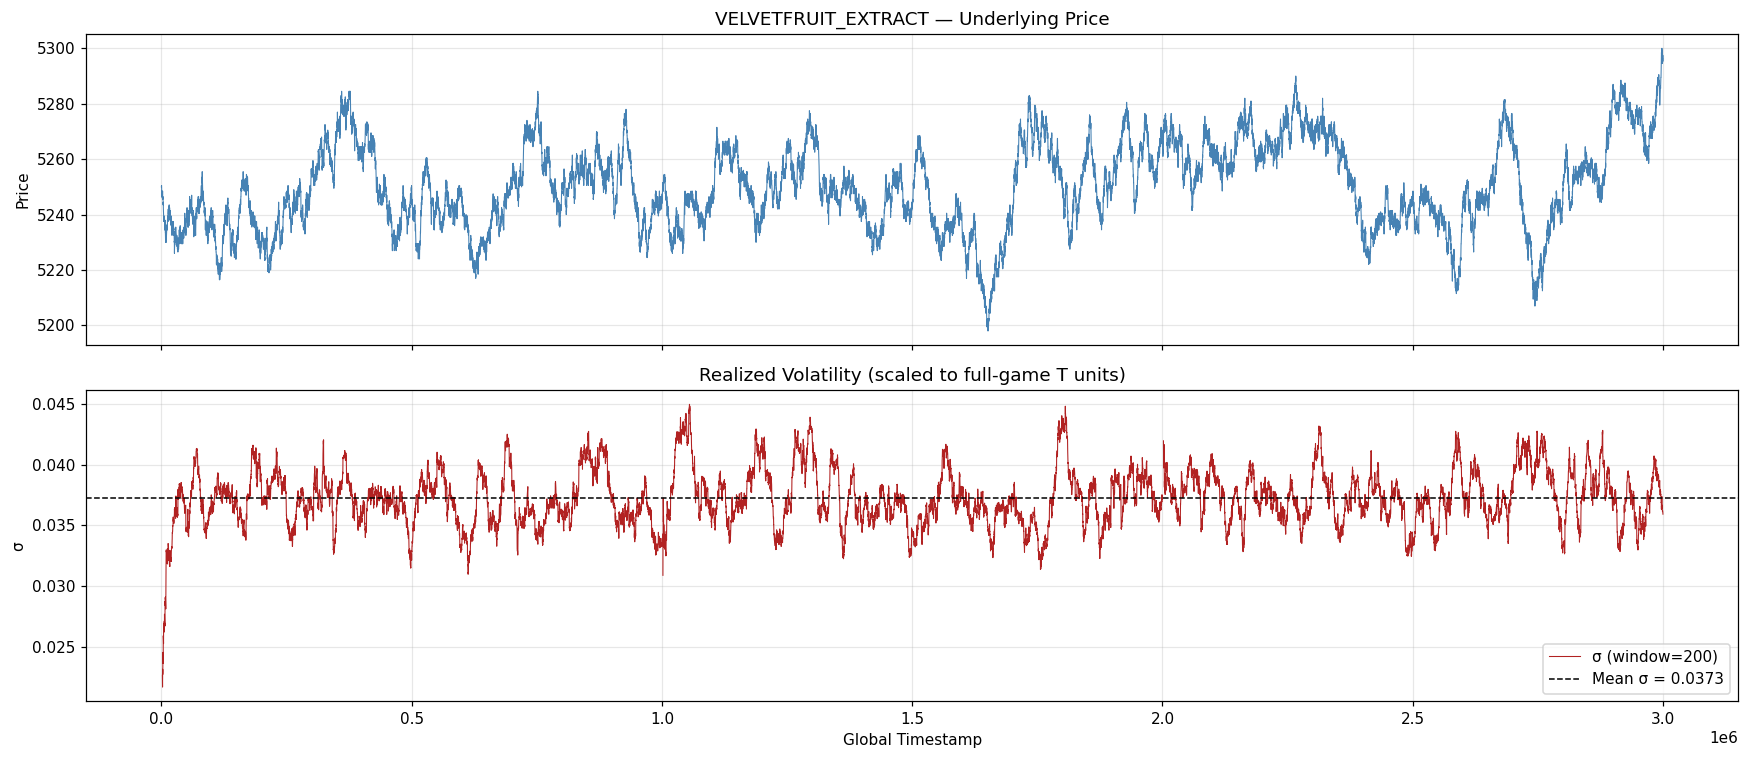

Realized vol stats (σ in T-units):
count    29940.000000
mean         0.037282
std          0.002299
min          0.021664
25%          0.035805
50%          0.037144
75%          0.038687
max          0.045001
Name: sigma, dtype: float64

Median σ used for proxy: 0.0371


In [5]:
VOL_WINDOW = 200   # ticks

und_ts = pivot[['global_ts','day','S']].dropna(subset=['S']).copy().reset_index(drop=True)
und_ts['log_ret'] = und_ts.groupby('day')['S'].transform(
    lambda x: np.log(x / x.shift(1))
)
und_ts['realized_vol'] = und_ts.groupby('day')['log_ret'].transform(
    lambda x: x.rolling(VOL_WINDOW, min_periods=20).std()
)

# Annualise / scale: 10000 ticks/day, 3 days → scale to per-unit-T
# Total ticks = 30000; vol per tick → vol per unit T (where T=1 = full game)
TOTAL_TICKS = len(und_ts)
und_ts['sigma'] = und_ts['realized_vol'] * np.sqrt(TOTAL_TICKS)

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
axes[0].plot(und_ts['global_ts'], und_ts['S'], linewidth=0.7, color='steelblue')
axes[0].set_title(f'VELVETFRUIT_EXTRACT — Underlying Price')
axes[0].set_ylabel('Price'); axes[0].grid(alpha=0.3)

axes[1].plot(und_ts['global_ts'], und_ts['sigma'], linewidth=0.7, color='firebrick', label=f'σ (window={VOL_WINDOW})')
axes[1].axhline(und_ts['sigma'].mean(), color='black', linestyle='--', linewidth=1,
                label=f'Mean σ = {und_ts["sigma"].mean():.4f}')
axes[1].set_title('Realized Volatility (scaled to full-game T units)')
axes[1].set_ylabel('σ'); axes[1].set_xlabel('Global Timestamp')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

mean_sigma = und_ts['sigma'].median()
print(f"Realized vol stats (σ in T-units):")
print(und_ts['sigma'].describe())
print(f"\nMedian σ used for proxy: {mean_sigma:.4f}")

## 4. Theoretical Price Proxy

In [6]:
# Merge rolling vol into opts
opts = opts.merge(und_ts[['global_ts','realized_vol','sigma']], on='global_ts', how='left')

# Simple proxy: intrinsic + c * sigma * sqrt(T) * S
# c ≈ 0.4 is the ATM Black-Scholes approximation coefficient
# We calibrate c by minimising squared error vs market prices across all options
from numpy.polynomial import polynomial as P

valid = opts.dropna(subset=['sigma','T']).copy()
valid['time_component'] = valid['sigma'] * np.sqrt(valid['T']) * valid['S']

# Simple OLS: C - intrinsic = c * time_component  (no intercept)
tv = valid['time_value'].values
tc = valid['time_component'].values
mask = np.isfinite(tv) & np.isfinite(tc) & (tc > 0)
c_calib = np.dot(tc[mask], tv[mask]) / np.dot(tc[mask], tc[mask])
print(f"Calibrated c = {c_calib:.4f}  (BS ATM ≈ 0.4)")

# Also test with fixed c = 0.4
C_FIXED = 0.4

opts['proxy_calib']  = opts['intrinsic'] + c_calib * opts['sigma'] * np.sqrt(opts['T']) * opts['S']
opts['proxy_fixed']  = opts['intrinsic'] + C_FIXED * opts['sigma'] * np.sqrt(opts['T']) * opts['S']
opts['mispricing_calib'] = opts['C'] - opts['proxy_calib']   # + = overpriced, - = underpriced
opts['mispricing_fixed']  = opts['C'] - opts['proxy_fixed']

print(f"\nMispricing stats (calibrated proxy):")
print(opts.groupby('product')['mispricing_calib'].describe()[['mean','std','min','max']].round(2).to_string())

Calibrated c = 0.0975  (BS ATM ≈ 0.4)

Mispricing stats (calibrated proxy):
           mean   std    min    max
product                            
VEV_4000 -12.68  4.59 -26.27   3.02
VEV_4500 -12.68  4.58 -24.77   2.02
VEV_5000  -7.77  3.29 -16.58   2.96
VEV_5100   4.01  2.94  -4.47  15.55
VEV_5200  32.75  5.88  18.28  55.72
VEV_5300  34.06  6.51  17.71  59.56
VEV_5400   3.25  3.76  -5.79  21.03
VEV_5500  -6.05  3.58 -13.74   7.35
VEV_6000 -12.19  4.52 -20.39   0.50
VEV_6500 -12.19  4.52 -20.39   0.50


## 5. Time Series: Underlying + Option Prices

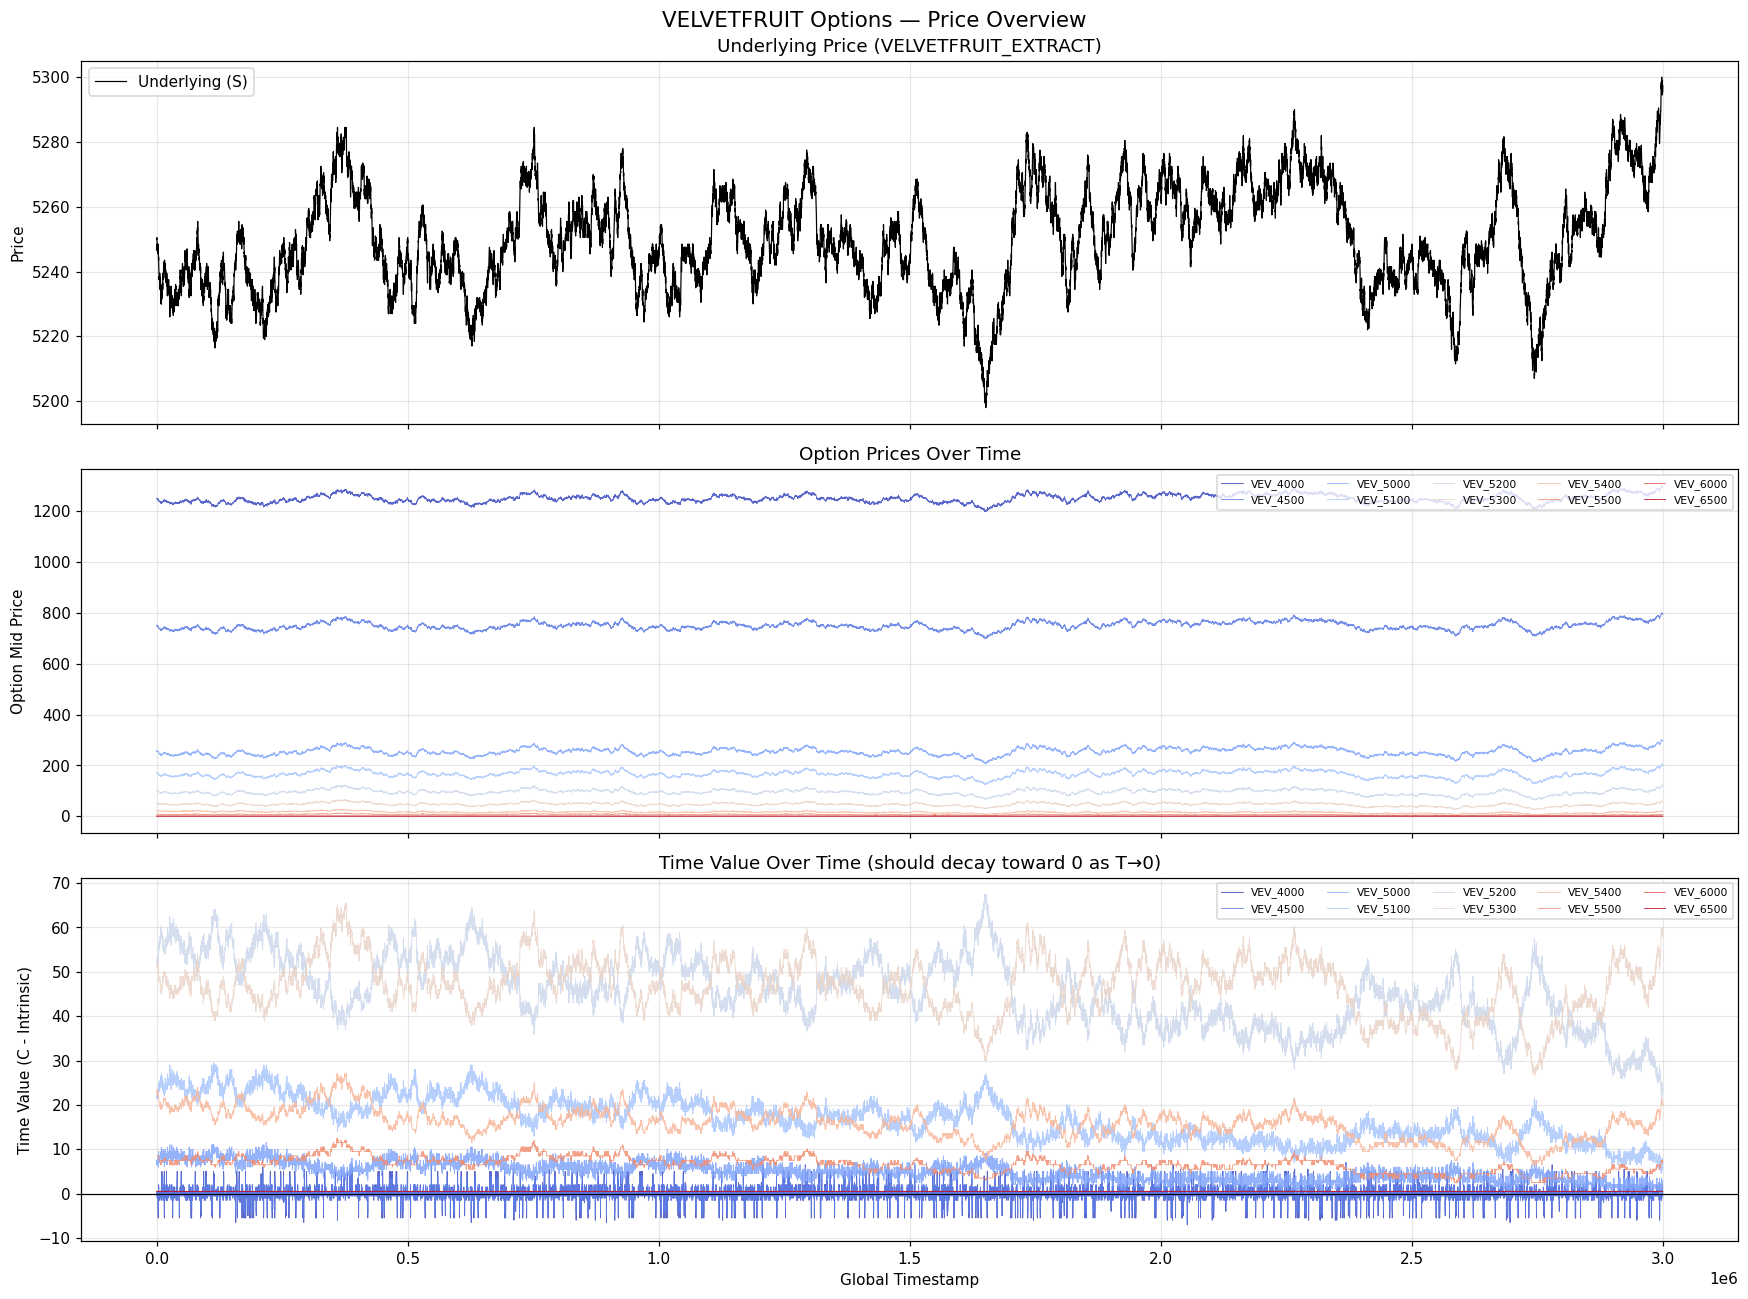

In [7]:
# Color options by moneyness: ITM=blue, ATM=green, OTM=red
itm  = [p for p in OPTION_PRODUCTS if STRIKES[p] < 5250]
atm  = [p for p in OPTION_PRODUCTS if 5200 <= STRIKES[p] <= 5300]
otm  = [p for p in OPTION_PRODUCTS if STRIKES[p] > 5250]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(pivot['global_ts'], pivot['S'], linewidth=0.8, color='black', label='Underlying (S)')
axes[0].set_ylabel('Price'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Underlying Price (VELVETFRUIT_EXTRACT)')

cmap = cm.get_cmap('coolwarm', len(OPTION_PRODUCTS))
for i, p in enumerate(OPTION_PRODUCTS):
    sub = opts[opts['product'] == p]
    axes[1].plot(sub['global_ts'], sub['C'], linewidth=0.6,
                 color=cmap(i), label=p, alpha=0.85)
axes[1].set_ylabel('Option Mid Price'); axes[1].grid(alpha=0.3)
axes[1].legend(ncol=5, fontsize=7, loc='upper right')
axes[1].set_title('Option Prices Over Time')

for i, p in enumerate(OPTION_PRODUCTS):
    sub = opts[opts['product'] == p]
    axes[2].plot(sub['global_ts'], sub['time_value'], linewidth=0.6,
                 color=cmap(i), label=p, alpha=0.85)
axes[2].axhline(0, color='black', linewidth=0.8)
axes[2].set_ylabel('Time Value (C - Intrinsic)'); axes[2].set_xlabel('Global Timestamp'); axes[2].grid(alpha=0.3)
axes[2].legend(ncol=5, fontsize=7, loc='upper right')
axes[2].set_title('Time Value Over Time (should decay toward 0 as T→0)')

plt.suptitle('VELVETFRUIT Options — Price Overview', fontsize=14)
plt.tight_layout(); plt.show()

## 6. Intrinsic vs Actual Price

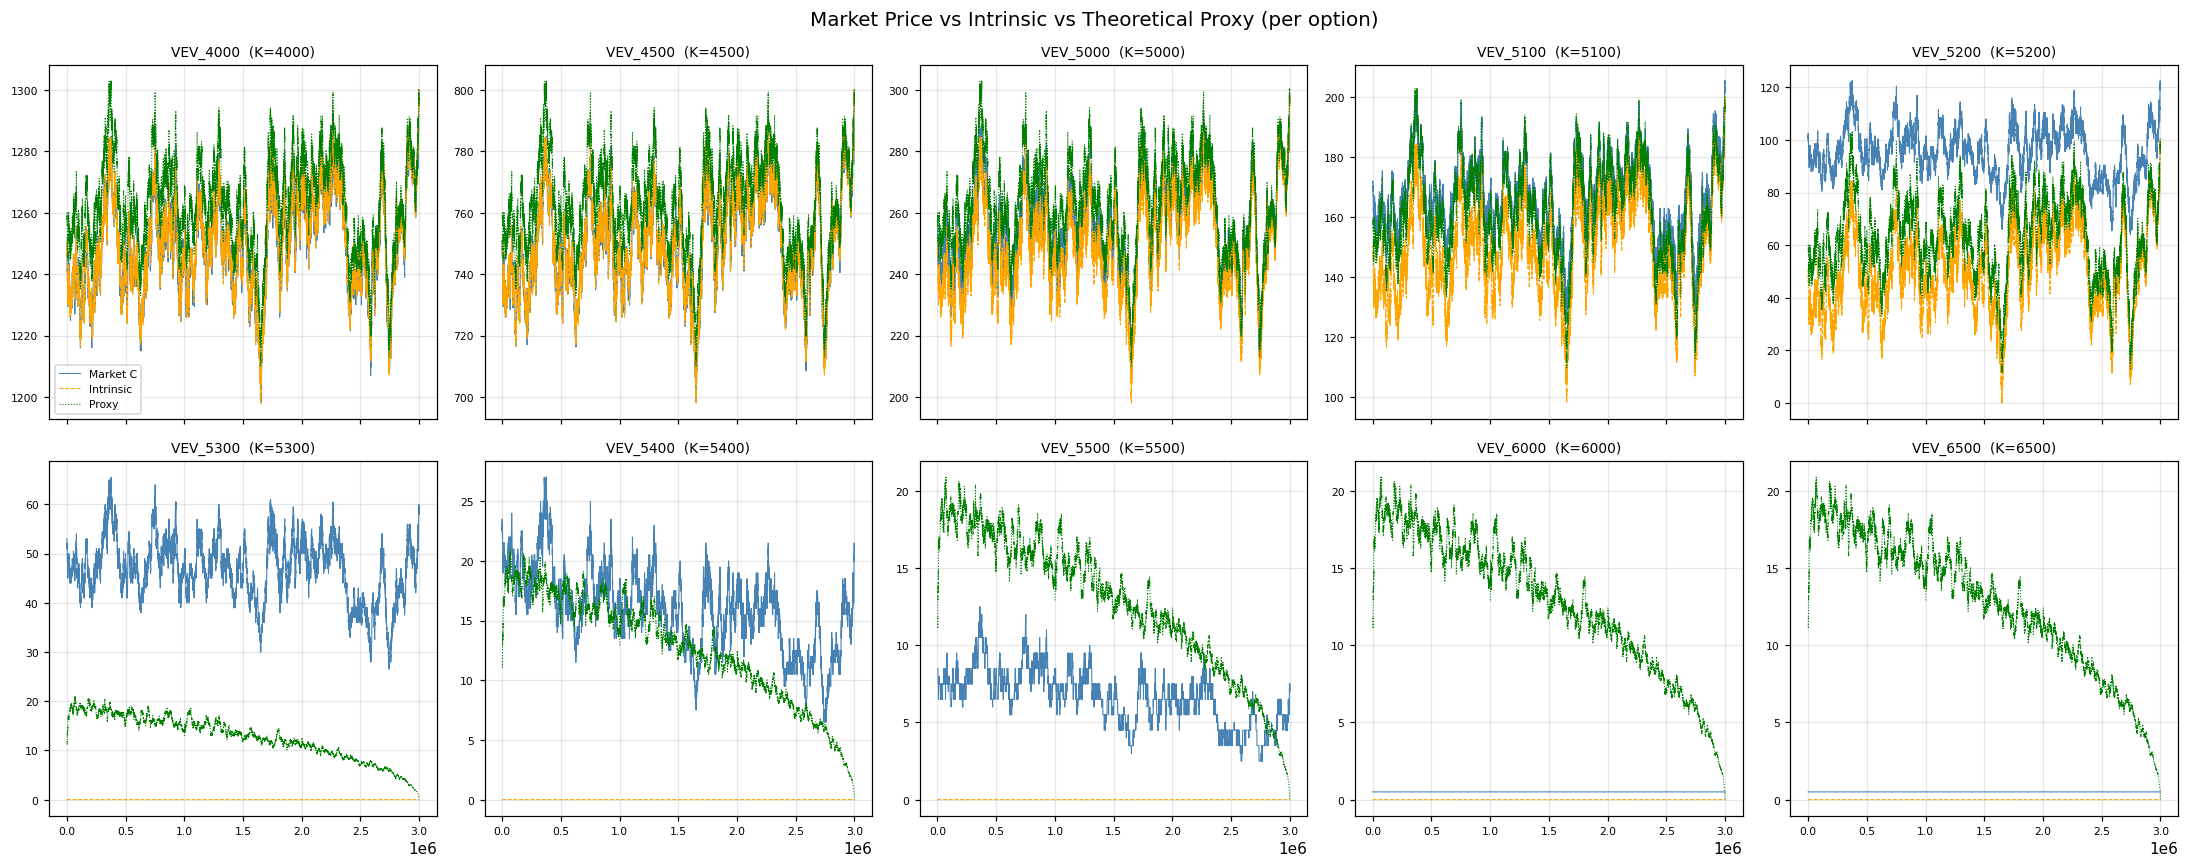

In [8]:
ncols = 5
nrows = 2
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8), sharex=True)
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K = STRIKES[product]
    sub = opts[opts['product'] == product]
    ax.plot(sub['global_ts'], sub['C'],         linewidth=0.7, color='steelblue', label='Market C')
    ax.plot(sub['global_ts'], sub['intrinsic'], linewidth=0.7, color='orange',    linestyle='--', label='Intrinsic')
    ax.plot(sub['global_ts'], sub['proxy_calib'], linewidth=0.7, color='green',   linestyle=':',  label='Proxy')
    ax.set_title(f'{product}  (K={K})', fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle('Market Price vs Intrinsic vs Theoretical Proxy (per option)', fontsize=13)
plt.tight_layout(); plt.show()

## 7. Time Value Decay

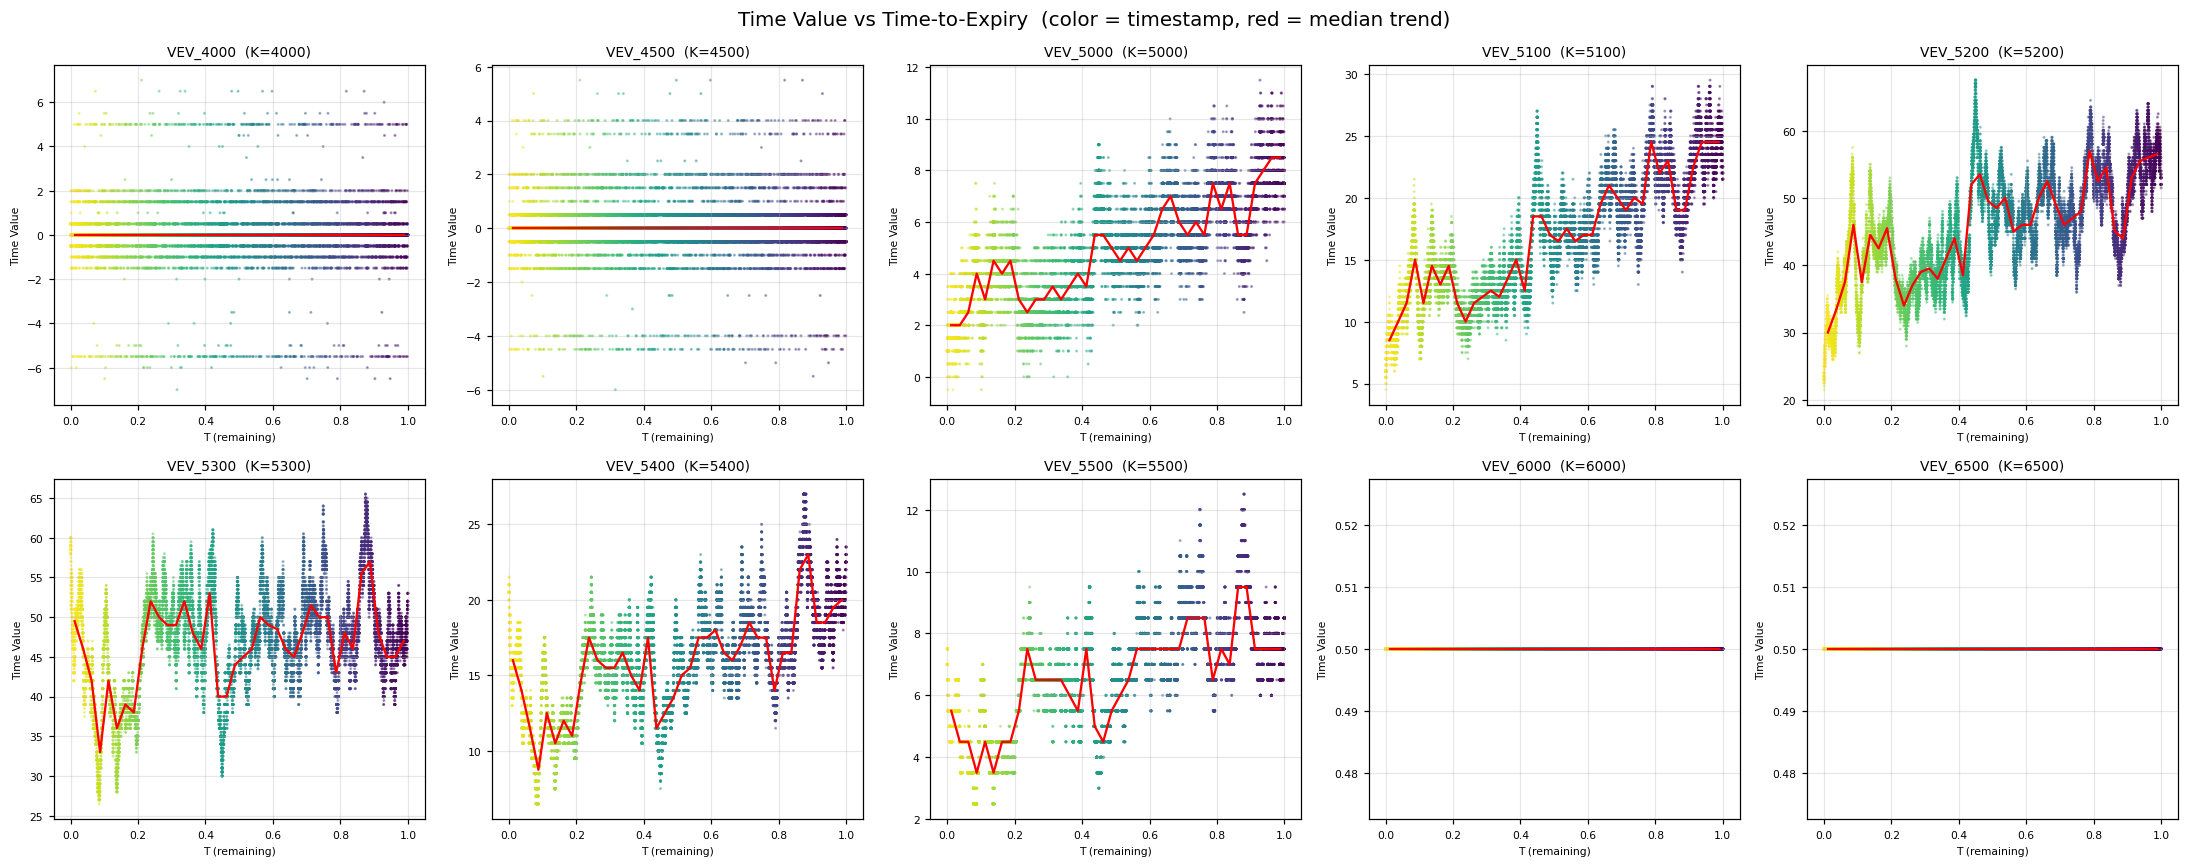

In [9]:
# Expected: time value should decrease as T→0 (theta decay)
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 8))
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K = STRIKES[product]
    sub = opts[opts['product'] == product].dropna(subset=['T','time_value'])
    sc = ax.scatter(sub['T'], sub['time_value'], s=1, c=sub['global_ts'],
                    cmap='viridis', alpha=0.4)
    # Smooth trend
    if len(sub) > 50:
        bins = pd.cut(sub['T'], bins=40)
        trend = sub.groupby(bins, observed=True)['time_value'].median()
        bin_mids = [b.mid for b in trend.index]
        ax.plot(bin_mids, trend.values, color='red', linewidth=1.5)
    ax.set_title(f'{product}  (K={K})', fontsize=9)
    ax.set_xlabel('T (remaining)', fontsize=7)
    ax.set_ylabel('Time Value', fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

plt.suptitle('Time Value vs Time-to-Expiry  (color = timestamp, red = median trend)', fontsize=13)
plt.tight_layout(); plt.show()

## 8. Cross-Sectional Analysis: Strike vs Price (Smile / Monotonicity)

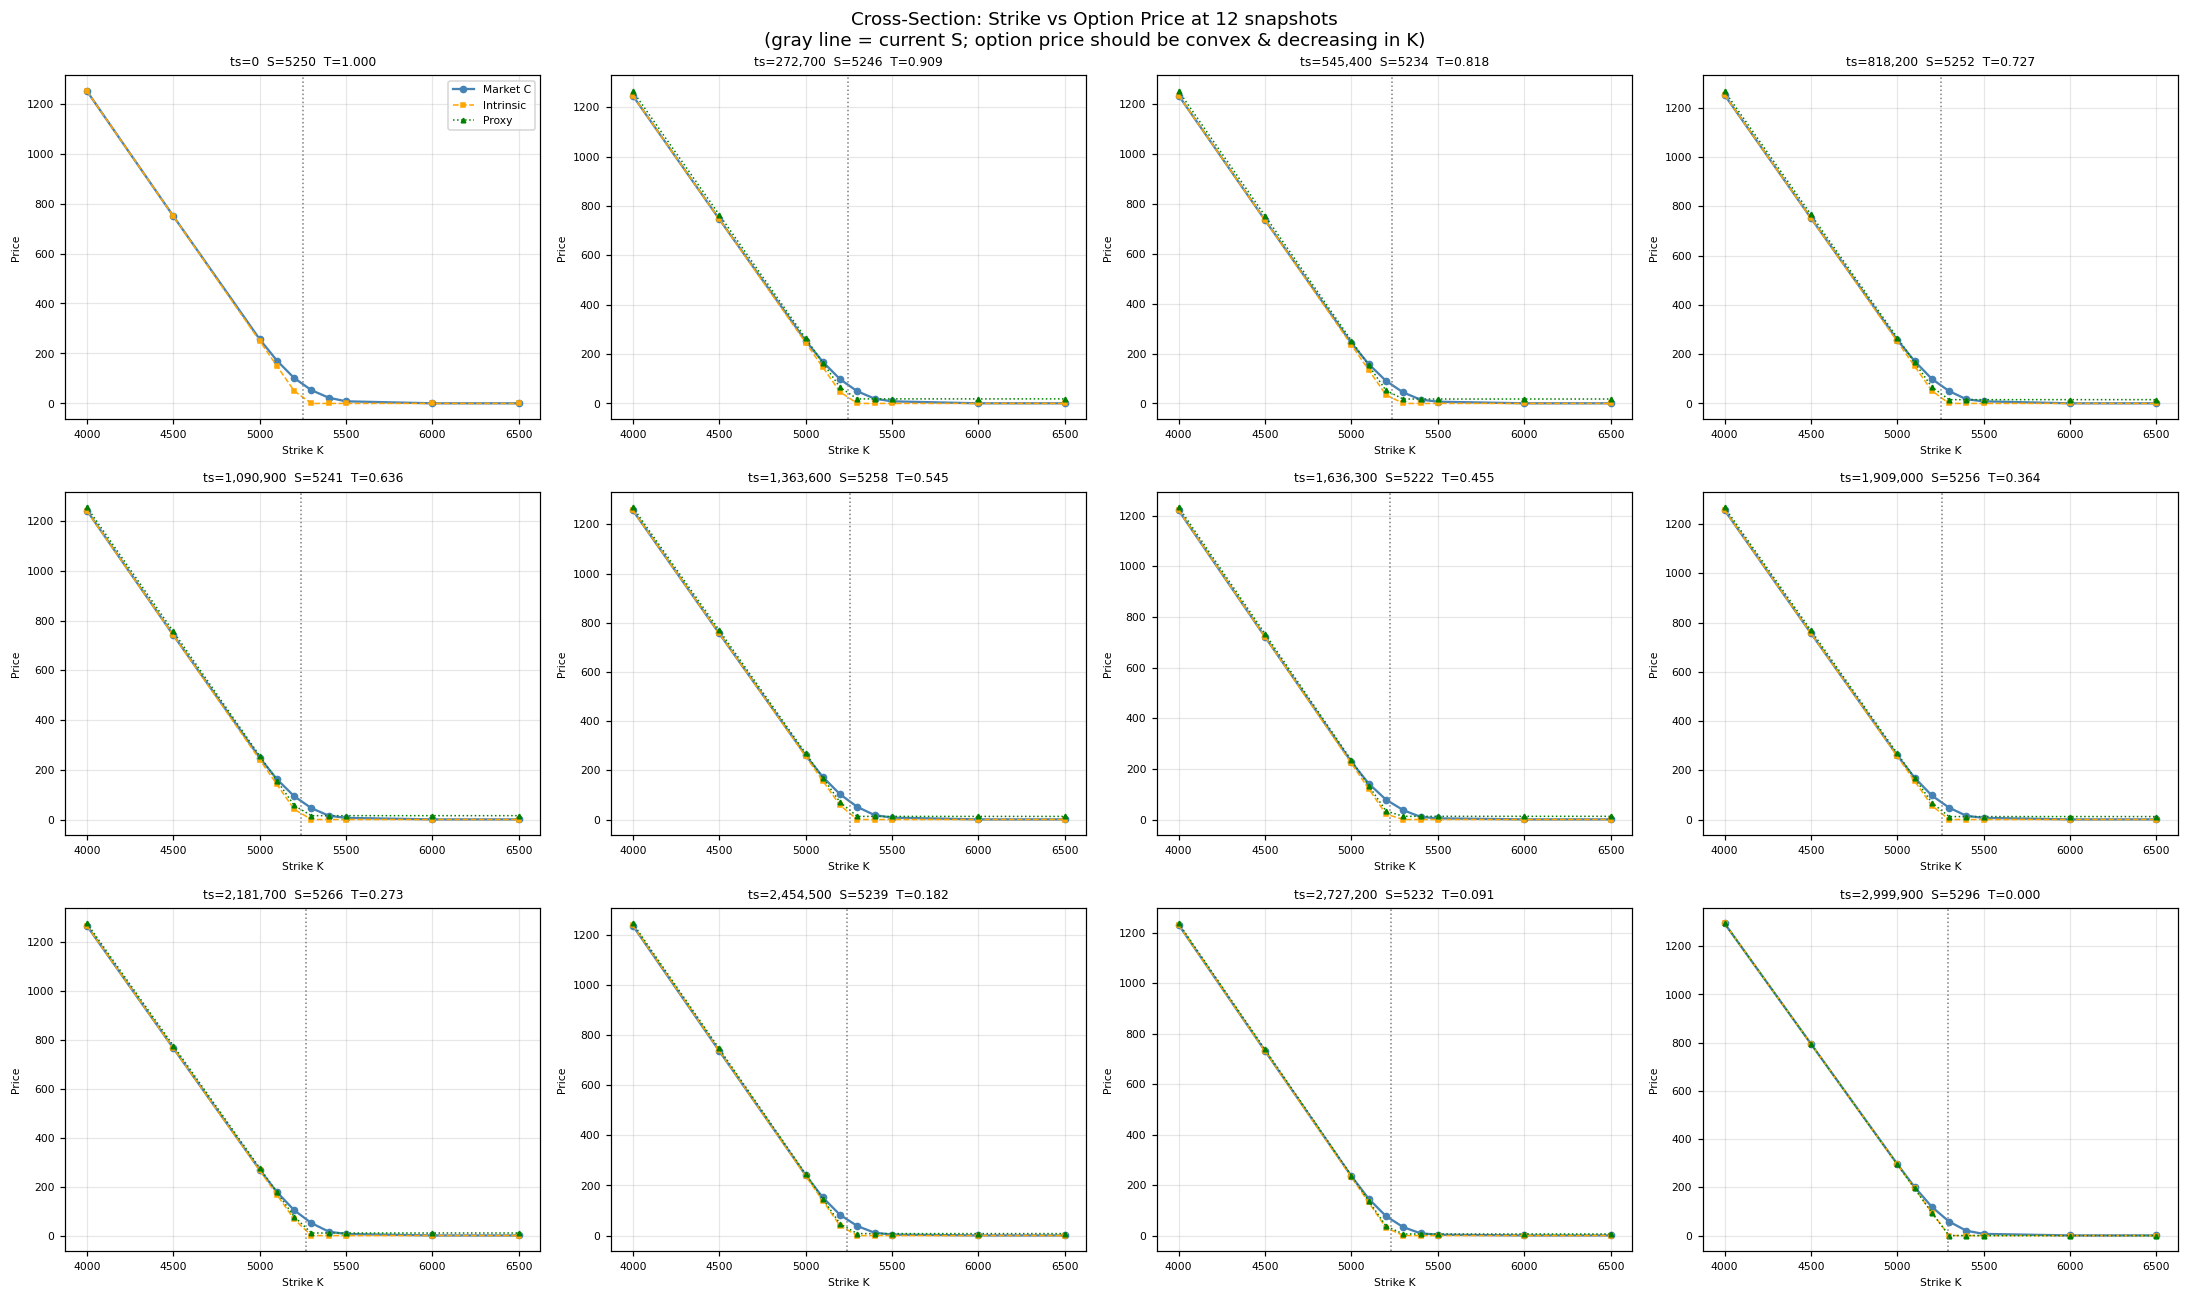

In [10]:
# Snapshot at evenly-spaced timestamps across all 3 days
snapshot_ts = np.linspace(pivot['global_ts'].min(), pivot['global_ts'].max(), 12, dtype=int)
# Find nearest actual timestamp for each snapshot
actual_ts = [pivot['global_ts'].iloc[(pivot['global_ts'] - t).abs().argmin()] for t in snapshot_ts]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flat

for ax, ts in zip(axes, actual_ts):
    snap = opts[opts['global_ts'] == ts].copy()
    if snap.empty:
        continue
    snap = snap.sort_values('K')
    S_val = snap['S'].iloc[0]
    T_val = snap['T'].iloc[0]

    ax.plot(snap['K'], snap['C'],         'o-', color='steelblue',  linewidth=1.5, markersize=4, label='Market C')
    ax.plot(snap['K'], snap['intrinsic'], 's--', color='orange',    linewidth=1,   markersize=3, label='Intrinsic')
    ax.plot(snap['K'], snap['proxy_calib'], '^:', color='green',    linewidth=1,   markersize=3, label='Proxy')
    ax.axvline(S_val, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'ts={ts:,}  S={S_val:.0f}  T={T_val:.3f}', fontsize=8)
    ax.set_xlabel('Strike K', fontsize=7)
    ax.set_ylabel('Price', fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle('Cross-Section: Strike vs Option Price at 12 snapshots\n(gray line = current S; option price should be convex & decreasing in K)', fontsize=12)
plt.tight_layout(); plt.show()

In [11]:
# Detect monotonicity violations: for calls, C(K1) >= C(K2) when K1 < K2
violations = []
for ts, grp in opts.groupby('global_ts'):
    grp = grp.sort_values('K')
    prices = grp['C'].values
    strikes = grp['K'].values
    for i in range(len(prices) - 1):
        if prices[i] < prices[i+1]:  # lower strike should have higher (or equal) price
            violations.append({'global_ts': ts, 'K_low': strikes[i], 'K_high': strikes[i+1],
                                'C_low': prices[i], 'C_high': prices[i+1],
                                'violation': prices[i+1] - prices[i]})

viol_df = pd.DataFrame(violations)
print(f"Monotonicity violations: {len(viol_df):,} out of {opts['global_ts'].nunique():,} timestamps")
if len(viol_df) > 0:
    print(f"\nMost common violating strike pairs:")
    print(viol_df.groupby(['K_low','K_high'])['violation'].agg(['count','mean']).sort_values('count', ascending=False).head(10))

Monotonicity violations: 0 out of 30,000 timestamps


In [12]:
# Convexity check: for calls, price should be convex in K
# Butterfly spread = C(K-dK) - 2*C(K) + C(K+dK) should be >= 0
convex_violations = []
sorted_strikes = sorted(STRIKES.values())
strike_to_product = {v: k for k, v in STRIKES.items()}

for ts, grp in opts.groupby('global_ts'):
    price_map = dict(zip(grp['K'], grp['C']))
    for i in range(1, len(sorted_strikes) - 1):
        K0, K1, K2 = sorted_strikes[i-1], sorted_strikes[i], sorted_strikes[i+1]
        if K0 in price_map and K1 in price_map and K2 in price_map:
            butterfly = price_map[K0] - 2*price_map[K1] + price_map[K2]
            if butterfly < -0.1:  # small tolerance
                convex_violations.append({'global_ts': ts, 'K_mid': K1, 'butterfly': butterfly})

cv_df = pd.DataFrame(convex_violations)
print(f"Convexity violations: {len(cv_df):,}")
if len(cv_df) > 0:
    print(f"\nViolations by strike:")
    print(cv_df.groupby('K_mid')['butterfly'].agg(['count','mean','min']).round(3))

Convexity violations: 9

Violations by strike:
       count  mean  min
K_mid                  
5500       9  -0.5 -0.5


## 9. Mispricing Analysis

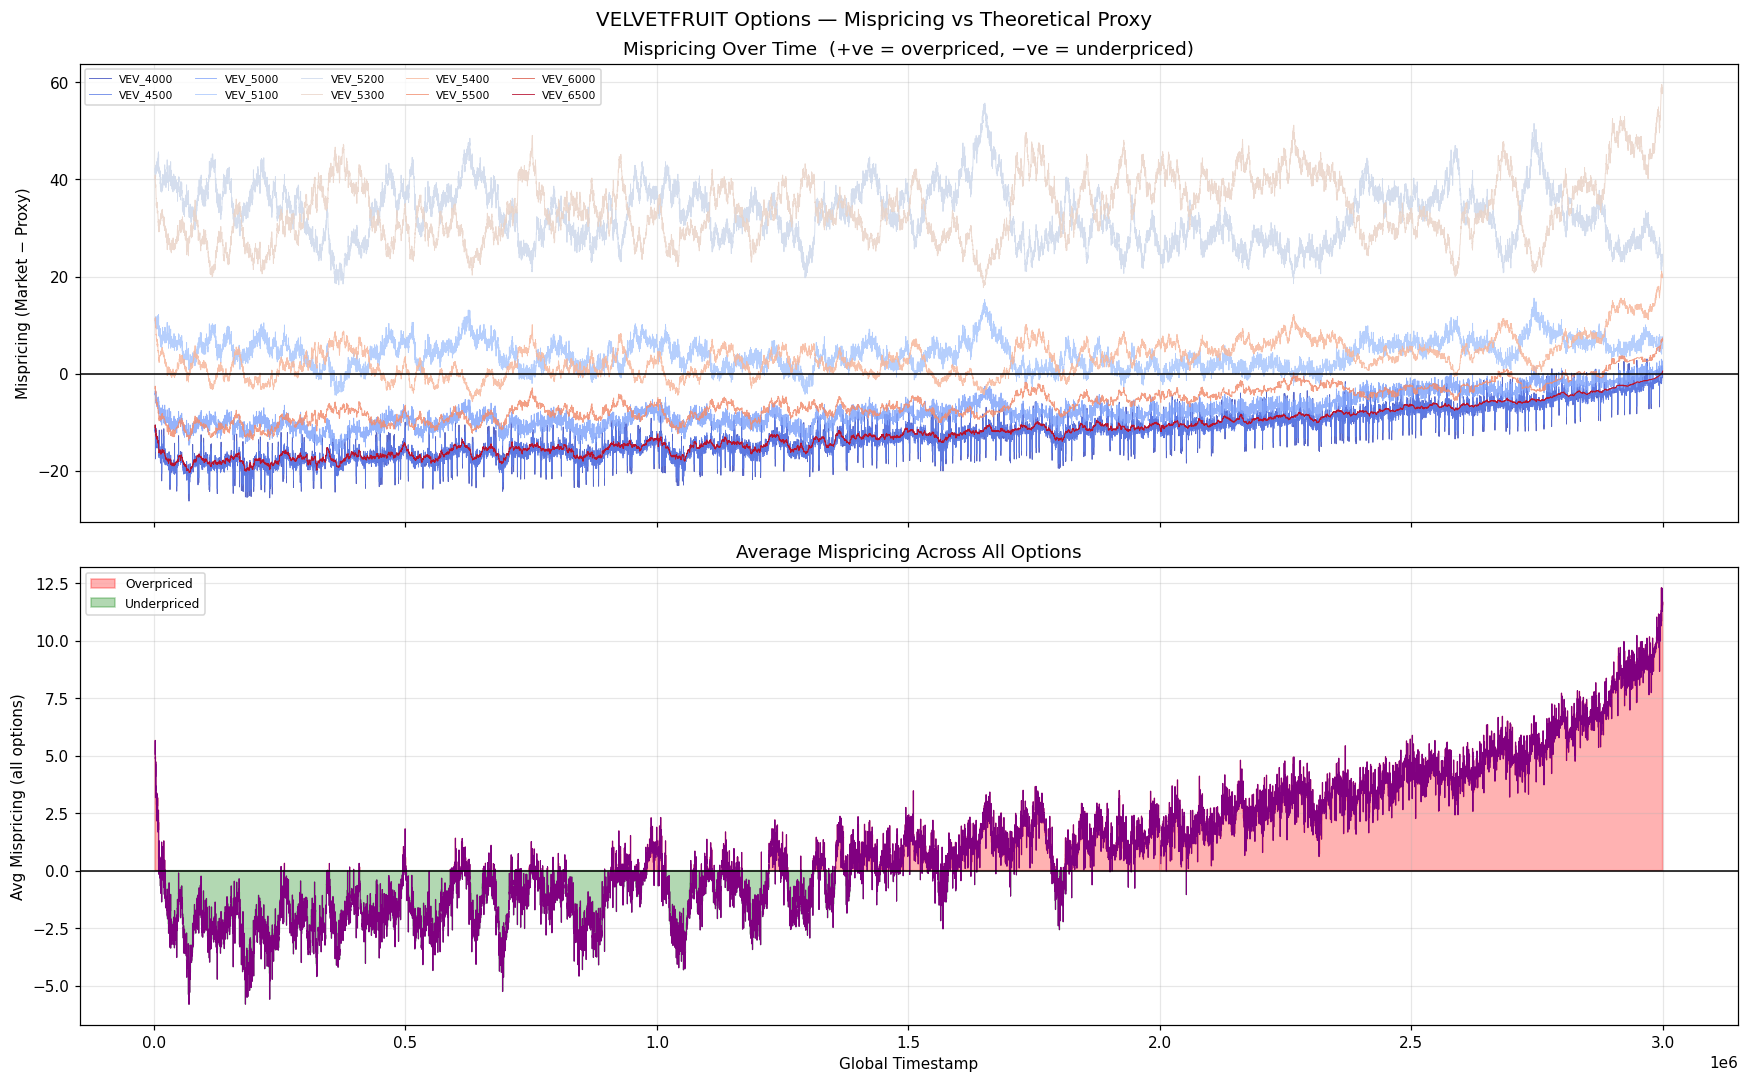

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
cmap = cm.get_cmap('coolwarm', len(OPTION_PRODUCTS))

for i, p in enumerate(OPTION_PRODUCTS):
    sub = opts[opts['product'] == p].dropna(subset=['mispricing_calib'])
    axes[0].plot(sub['global_ts'], sub['mispricing_calib'], linewidth=0.6,
                 color=cmap(i), label=p, alpha=0.85)
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_ylabel('Mispricing (Market − Proxy)')
axes[0].set_title('Mispricing Over Time  (+ve = overpriced, −ve = underpriced)')
axes[0].legend(ncol=5, fontsize=7)
axes[0].grid(alpha=0.3)

# Aggregate absolute mispricing
agg_misprice = opts.groupby('global_ts')['mispricing_calib'].mean()
axes[1].plot(agg_misprice.index, agg_misprice.values, linewidth=0.7, color='purple')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].fill_between(agg_misprice.index, 0, agg_misprice.values,
                     where=agg_misprice.values > 0, alpha=0.3, color='red', label='Overpriced')
axes[1].fill_between(agg_misprice.index, 0, agg_misprice.values,
                     where=agg_misprice.values < 0, alpha=0.3, color='green', label='Underpriced')
axes[1].set_ylabel('Avg Mispricing (all options)')
axes[1].set_xlabel('Global Timestamp')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)
axes[1].set_title('Average Mispricing Across All Options')

plt.suptitle('VELVETFRUIT Options — Mispricing vs Theoretical Proxy', fontsize=13)
plt.tight_layout(); plt.show()

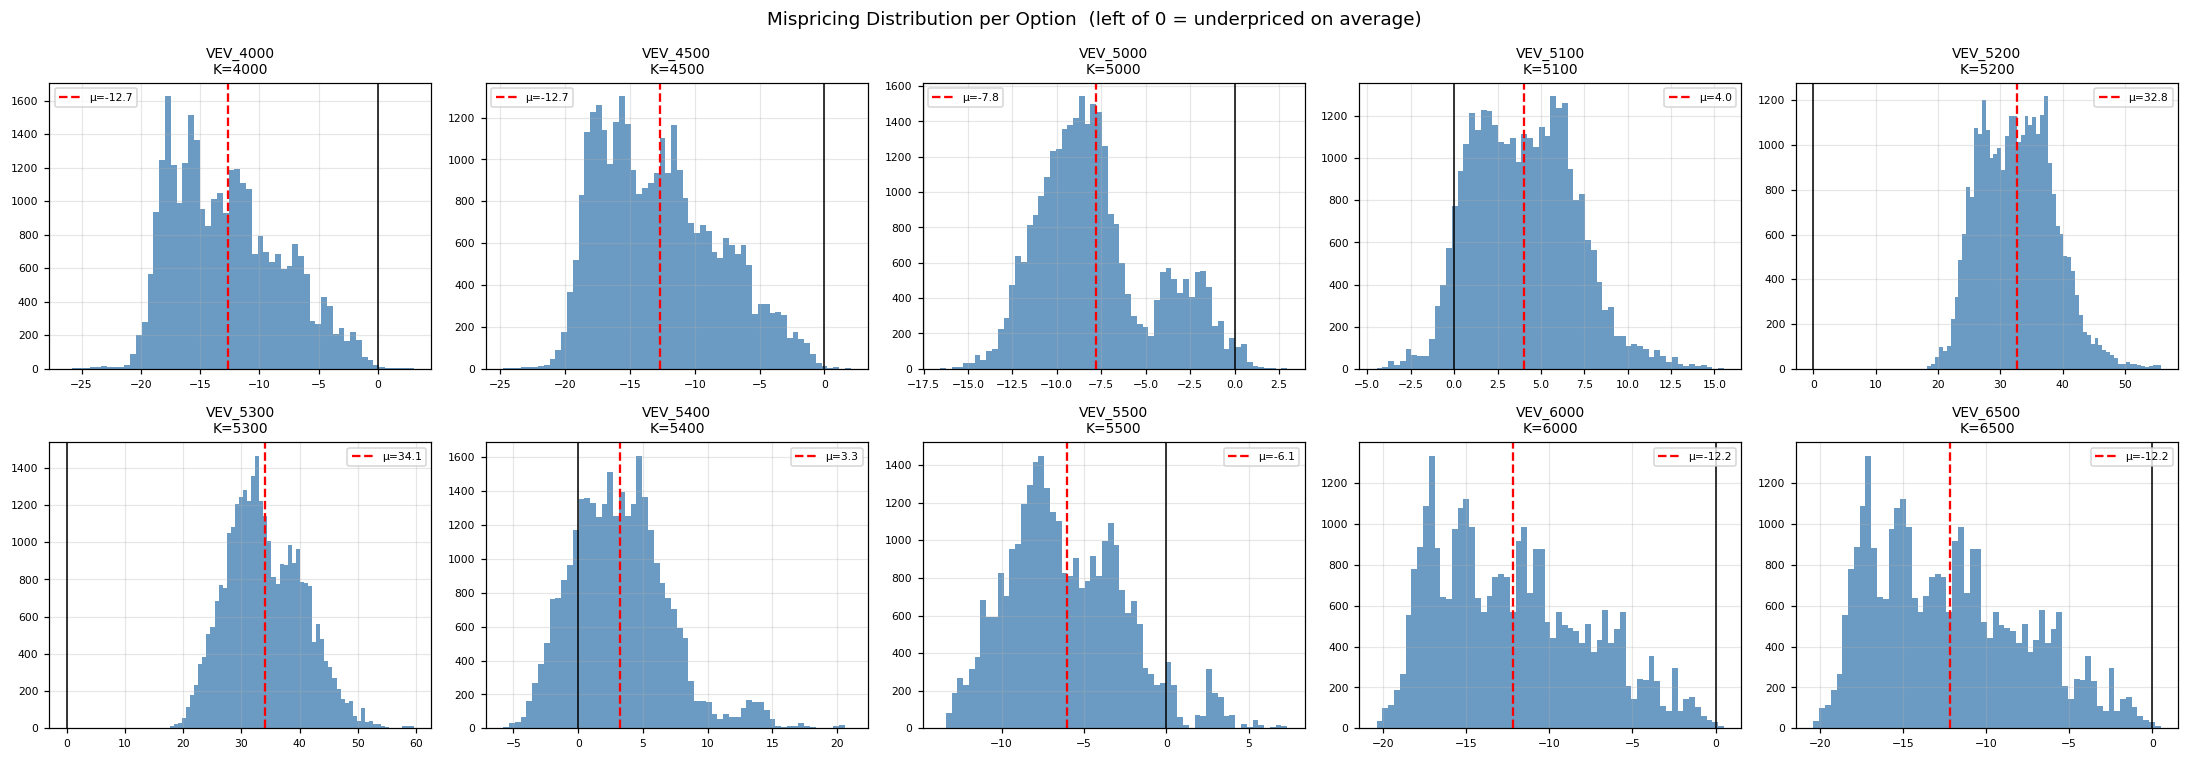

In [14]:
# Mispricing distribution per option
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K = STRIKES[product]
    sub = opts[opts['product'] == product]['mispricing_calib'].dropna()
    ax.hist(sub, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0,        color='black', linewidth=1)
    ax.axvline(sub.mean(), color='red',   linewidth=1.5, linestyle='--',
               label=f'μ={sub.mean():.1f}')
    ax.set_title(f'{product}\nK={K}', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

plt.suptitle('Mispricing Distribution per Option  (left of 0 = underpriced on average)', fontsize=12)
plt.tight_layout(); plt.show()

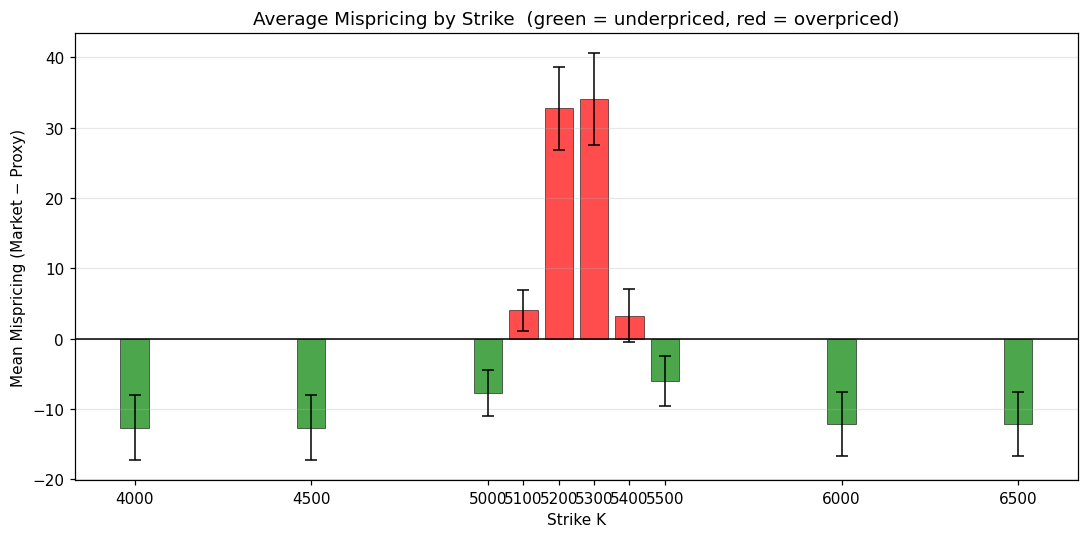


Mispricing by strike (mean ± std):
       mean   std  median
K                        
4000 -12.68  4.59  -13.21
4500 -12.68  4.58  -13.19
5000  -7.77  3.29   -8.35
5100   4.01  2.94    3.95
5200  32.75  5.88   32.57
5300  34.06  6.51   33.27
5400   3.25  3.76    3.00
5500  -6.05  3.58   -6.59
6000 -12.19  4.52  -12.74
6500 -12.19  4.52  -12.74


In [15]:
# Strike vs average mispricing (cross-section)
misprice_by_strike = opts.groupby('K')['mispricing_calib'].agg(['mean','std','median'])

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(misprice_by_strike.index, misprice_by_strike['mean'],
       color=['green' if v < 0 else 'red' for v in misprice_by_strike['mean']],
       alpha=0.7, width=80, edgecolor='black', linewidth=0.5, label='Mean mispricing')
ax.errorbar(misprice_by_strike.index, misprice_by_strike['mean'],
            yerr=misprice_by_strike['std'], fmt='none', color='black', capsize=4, linewidth=1)
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Strike K'); ax.set_ylabel('Mean Mispricing (Market − Proxy)')
ax.set_title('Average Mispricing by Strike  (green = underpriced, red = overpriced)')
ax.set_xticks(sorted(STRIKES.values()))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print("\nMispricing by strike (mean ± std):")
print(misprice_by_strike.round(2))

## 10. Strike vs Time Value (Smile Detection)

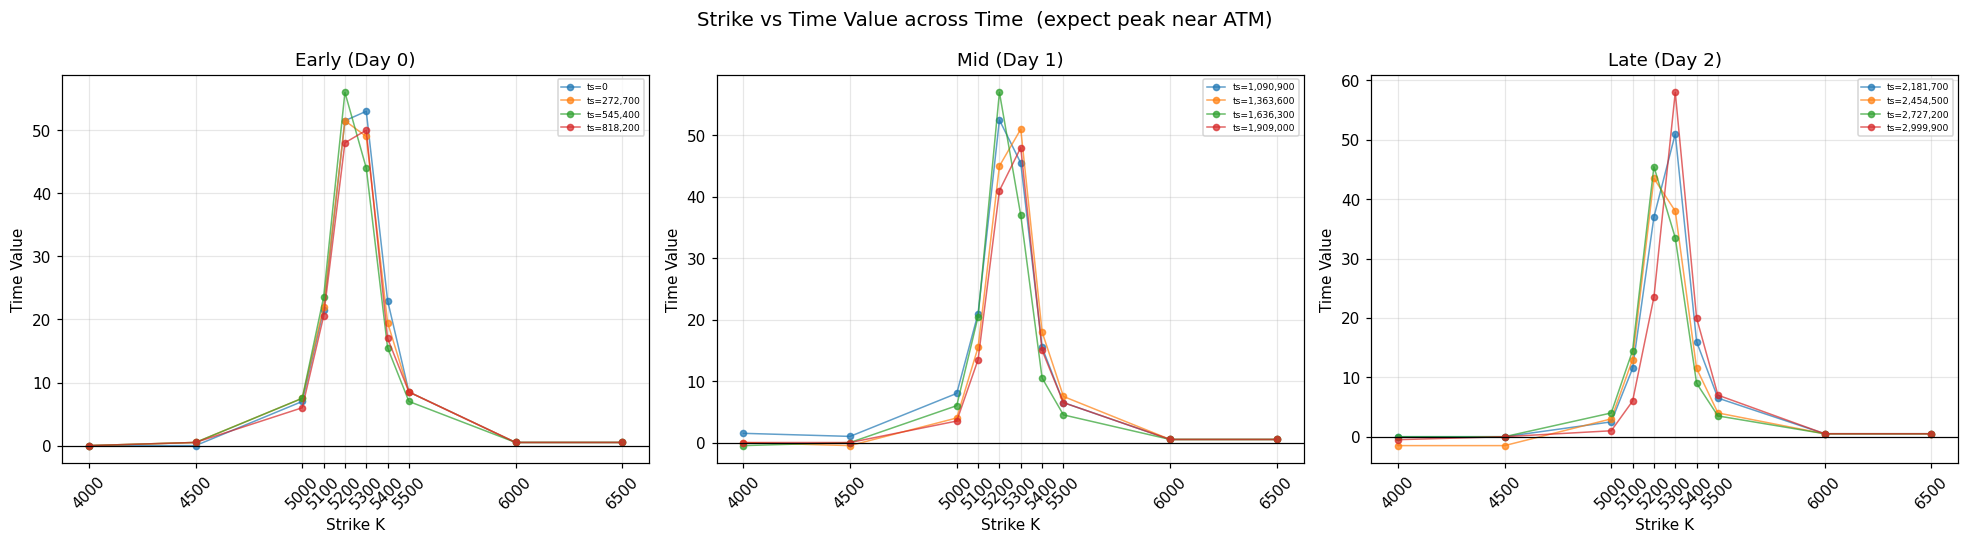

In [16]:
# Plot strike vs time value at multiple snapshots — expect a hump near ATM
early_ts  = actual_ts[:4]
mid_ts    = actual_ts[4:8]
late_ts   = actual_ts[8:]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['Early (Day 0)', 'Mid (Day 1)', 'Late (Day 2)']

for ax, ts_group, title in zip(axes, [early_ts, mid_ts, late_ts], titles):
    for ts in ts_group:
        snap = opts[opts['global_ts'] == ts].sort_values('K')
        if snap.empty: continue
        ax.plot(snap['K'], snap['time_value'], 'o-', markersize=4, linewidth=1, alpha=0.7,
                label=f'ts={ts:,}')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title); ax.set_xlabel('Strike K'); ax.set_ylabel('Time Value')
    ax.legend(fontsize=6); ax.grid(alpha=0.3)
    ax.set_xticks(sorted(STRIKES.values())); ax.tick_params(axis='x', rotation=45)

plt.suptitle('Strike vs Time Value across Time  (expect peak near ATM)', fontsize=13)
plt.tight_layout(); plt.show()

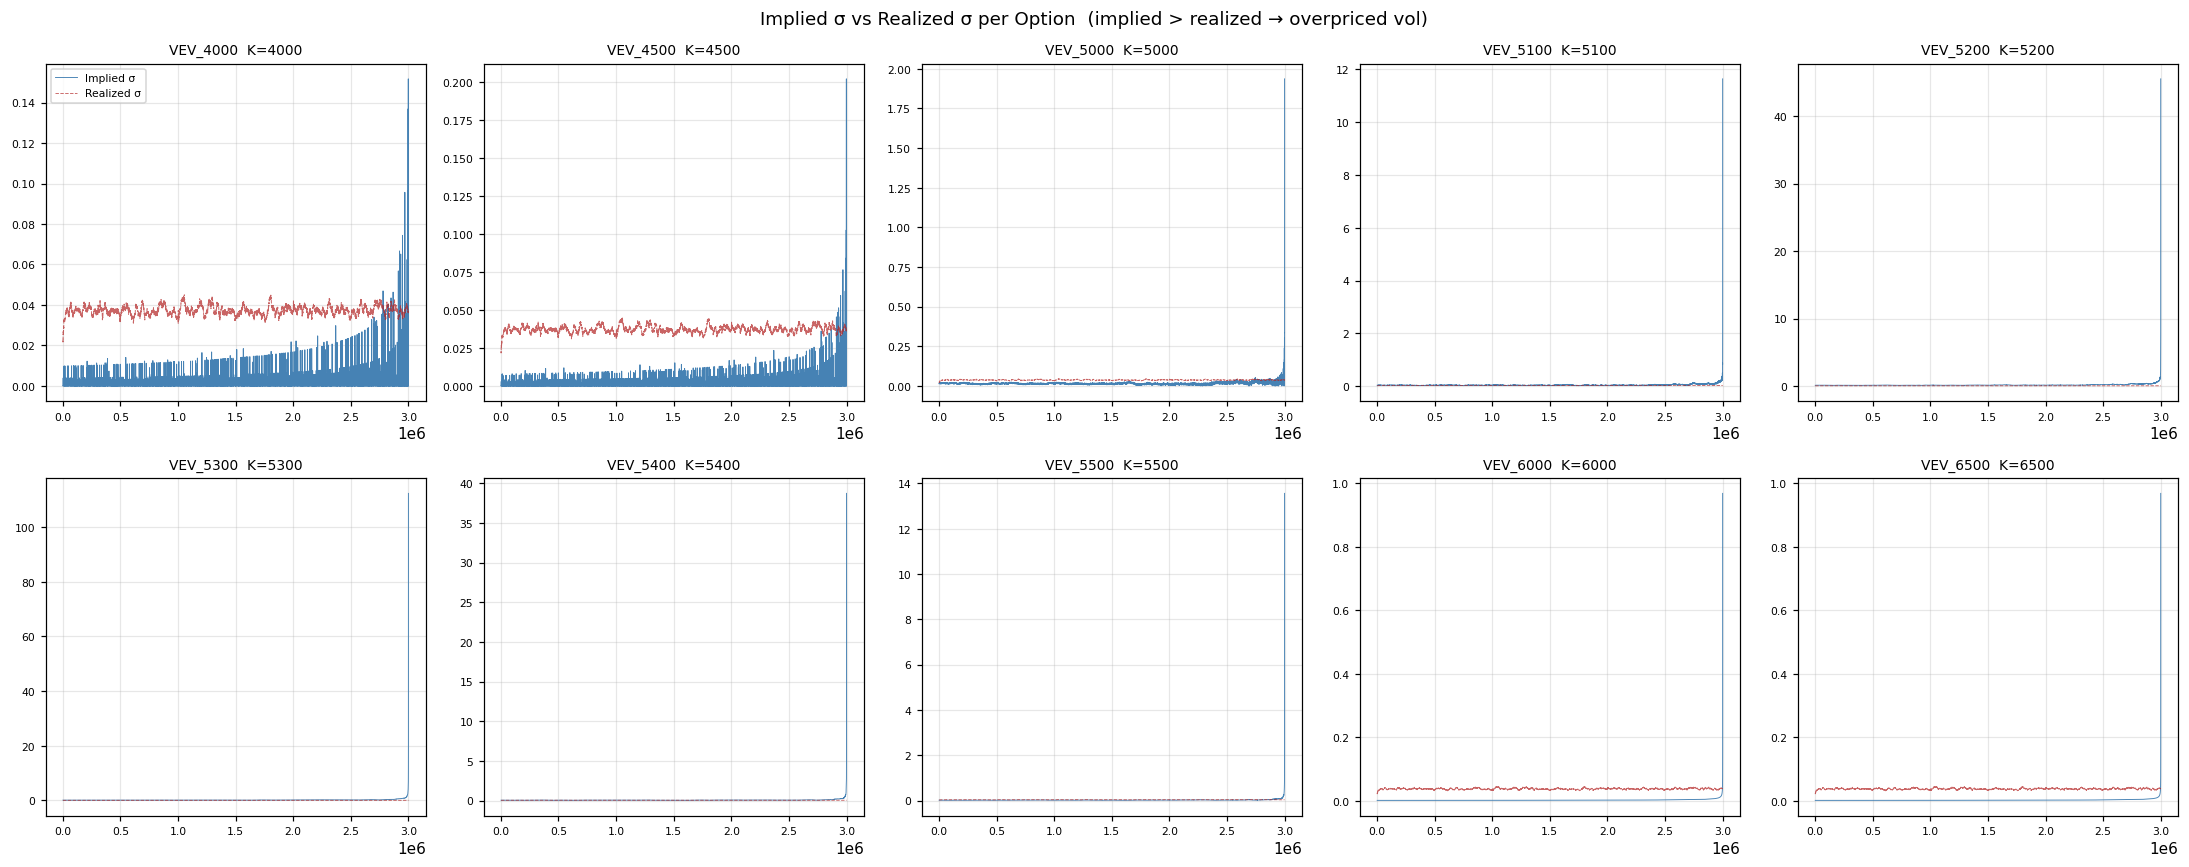

In [17]:
# Implied vol proxy: back out σ_implied from market price
# C = intrinsic + c * σ_impl * sqrt(T) * S  →  σ_impl = (C - intrinsic) / (c * sqrt(T) * S)
opts['sigma_implied'] = (opts['time_value']) / (c_calib * np.sqrt(opts['T'].clip(1e-6)) * opts['S'])
opts['sigma_implied'] = opts['sigma_implied'].clip(0)

# Merge realized vol for comparison
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K = STRIKES[product]
    sub = opts[opts['product'] == product].dropna(subset=['sigma_implied','realized_vol'])
    ax.plot(sub['global_ts'], sub['sigma_implied'], linewidth=0.6, color='steelblue', label='Implied σ')
    ax.plot(sub['global_ts'], sub['sigma'],         linewidth=0.6, color='firebrick',
            linestyle='--', alpha=0.7, label='Realized σ')
    ax.set_title(f'{product}  K={K}', fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=7)
plt.suptitle('Implied σ vs Realized σ per Option  (implied > realized → overpriced vol)', fontsize=12)
plt.tight_layout(); plt.show()

## 11. Summary Statistics & Trading Signals

In [18]:
print('=' * 70)
print('VELVETFRUIT OPTIONS — ANALYSIS SUMMARY')
print('=' * 70)

print(f"\nUnderlying (S):")
print(f"  Mean S:        {pivot['S'].mean():.2f}")
print(f"  Std S:         {pivot['S'].std():.2f}")
print(f"  Range:         {pivot['S'].min():.0f} – {pivot['S'].max():.0f}")
print(f"  Median σ (T):  {mean_sigma:.5f}")
print(f"  Calibrated c:  {c_calib:.4f}")

print(f"\n{'Product':<12} {'K':>6} {'C_mean':>8} {'Intr':>8} {'TV_mean':>8} {'Misprice':>10} {'Signal':>12}")
print('-' * 72)
for product in OPTION_PRODUCTS:
    K  = STRIKES[product]
    sub = opts[opts['product'] == product]
    c_mean  = sub['C'].mean()
    intr    = sub['intrinsic'].mean()
    tv      = sub['time_value'].mean()
    mp      = sub['mispricing_calib'].mean()
    signal  = 'BUY (under)' if mp < -1 else ('SELL (over)' if mp > 1 else 'NEUTRAL')
    print(f"{product:<12} {K:>6} {c_mean:>8.2f} {intr:>8.2f} {tv:>8.2f} {mp:>10.2f} {signal:>12}")

print(f"\n--- Monotonicity ---")
print(f"  Violations: {len(viol_df):,} ticks ({len(viol_df)/opts['global_ts'].nunique()*100:.1f}% of timestamps)")

print(f"\n--- Convexity ---")
print(f"  Violations: {len(cv_df):,} ticks")
if len(cv_df) > 0:
    print(f"  Worst strike: {cv_df.groupby('K_mid')['butterfly'].mean().idxmin()}")

print(f"\n--- Most Underpriced Option (largest negative mispricing) ---")
best_buy = opts.groupby('product')['mispricing_calib'].mean().idxmin()
print(f"  {best_buy}  (avg mispricing = {opts[opts['product']==best_buy]['mispricing_calib'].mean():.2f})")

print(f"\n--- Most Overpriced Option (largest positive mispricing) ---")
best_sell = opts.groupby('product')['mispricing_calib'].mean().idxmax()
print(f"  {best_sell}  (avg mispricing = {opts[opts['product']==best_sell]['mispricing_calib'].mean():.2f})")

VELVETFRUIT OPTIONS — ANALYSIS SUMMARY

Underlying (S):
  Mean S:        5250.10
  Std S:         15.63
  Range:         5198 – 5300
  Median σ (T):  0.03714
  Calibrated c:  0.0975

Product           K   C_mean     Intr  TV_mean   Misprice       Signal
------------------------------------------------------------------------
VEV_4000       4000  1250.11  1250.10     0.01     -12.68  BUY (under)
VEV_4500       4500   750.11   750.10     0.01     -12.68  BUY (under)
VEV_5000       5000   255.02   250.10     4.92      -7.77  BUY (under)
VEV_5100       5100   166.81   150.10    16.71       4.01  SELL (over)
VEV_5200       5200    95.55    50.10    45.45      32.75  SELL (over)
VEV_5300       5300    46.76     0.00    46.76      34.06  SELL (over)
VEV_5400       5400    15.95     0.00    15.95       3.25  SELL (over)
VEV_5500       5500     6.64     0.00     6.64      -6.05  BUY (under)
VEV_6000       6000     0.50     0.00     0.50     -12.19  BUY (under)
VEV_6500       6500     0.50     0

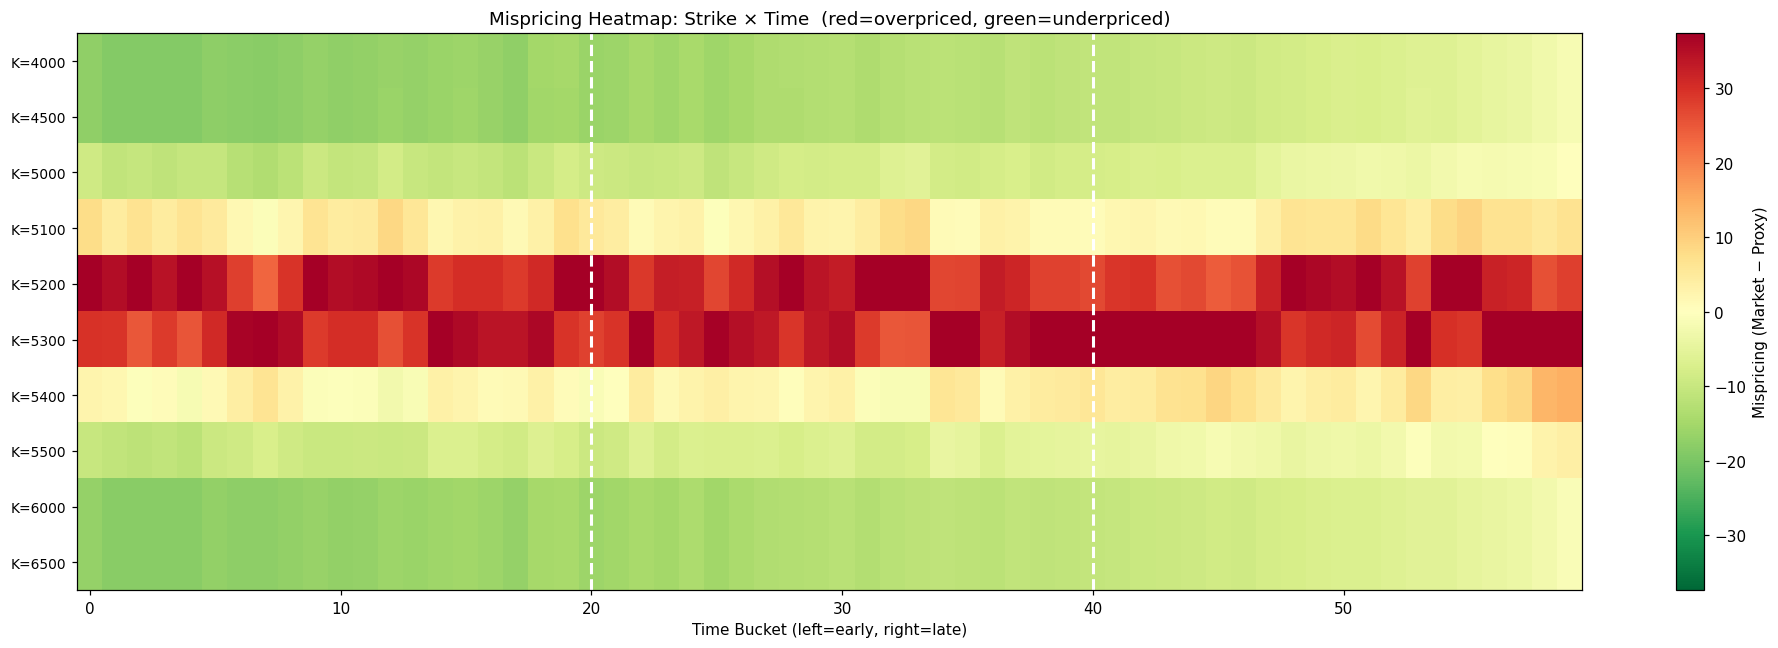

In [19]:
# Final heatmap: mispricing over time for each strike
# Bin timestamps into 60 buckets for readability
opts['ts_bin'] = pd.cut(opts['global_ts'], bins=60, labels=False)
heat = opts.pivot_table(index='K', columns='ts_bin', values='mispricing_calib', aggfunc='mean')

fig, ax = plt.subplots(figsize=(18, 6))
vmax = np.nanpercentile(np.abs(heat.values), 95)
im = ax.imshow(heat.values, aspect='auto', cmap='RdYlGn_r',
               vmin=-vmax, vmax=vmax, interpolation='nearest')
plt.colorbar(im, ax=ax, label='Mispricing (Market − Proxy)')
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels([f'K={k}' for k in heat.index], fontsize=9)
ax.set_xlabel('Time Bucket (left=early, right=late)')
ax.set_title('Mispricing Heatmap: Strike × Time  (red=overpriced, green=underpriced)')

# Day boundary lines
for day_end_frac in [1/3, 2/3]:
    ax.axvline(day_end_frac * 60, color='white', linewidth=2, linestyle='--')

plt.tight_layout(); plt.show()

## 12. Delta-Hedged Options Trading Strategy

In [20]:

from scipy.stats import norm

def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes European call price."""
    if T <= 1e-8 or sigma <= 1e-8 or S <= 0:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_delta(S, K, T, sigma, r=0.0):
    """Black-Scholes call delta = N(d1)."""
    if T <= 1e-8 or sigma <= 1e-8 or S <= 0:
        return 1.0 if S > K else 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

# Quick sanity check
print("BS call(S=5250, K=5200, T=0.5, σ=0.05):", round(bs_call(5250, 5200, 0.5, 0.05), 4))
print("BS delta(S=5250, K=5200, T=0.5, σ=0.05):", round(bs_delta(5250, 5200, 0.5, 0.05), 4))
print("BS call(S=5250, K=5300, T=0.5, σ=0.05):", round(bs_call(5250, 5300, 0.5, 0.05), 4))


BS call(S=5250, K=5200, T=0.5, σ=0.05): 101.3761
BS delta(S=5250, K=5200, T=0.5, σ=0.05): 0.6135
BS call(S=5250, K=5300, T=0.5, σ=0.05): 52.0562


In [26]:

# ── Strategy parameters ────────────────────────────────────────────────────
MISPRICE_THRESHOLD = 5.0    # open trade when |market − BS| > this
CLOSE_THRESHOLD    = 1.0    # close trade when |market − BS| < this
MAX_OPT_POS        = 10     # max units per option (each way)
OPT_LOT            = 1      # units traded per signal
UND_LIMIT          = 200    # position limit for the underlying hedge
VOL_WINDOW_BT      = 2000    # rolling window for realized vol in backtest

# ── Build per-product bid/ask arrays from raw data ────────────────────────
# We fill options at their bid (when selling) or ask (when buying)
opt_ba = {}
for product in OPTION_PRODUCTS:
    sub = raw[raw['product'] == product][
        ['global_ts','bid_price_1','ask_price_1','bid_volume_1','ask_volume_1']
    ].set_index('global_ts')
    opt_ba[product] = sub

# Underlying bid/ask (already in pivot)
und_bid = pivot.set_index('global_ts')['S_bid']
und_ask = pivot.set_index('global_ts')['S_ask']

# Underlying price series for rolling vol (per day, no cross-day contamination)
und_series = pivot[['global_ts','day','S']].dropna(subset=['S']).copy().reset_index(drop=True)
und_series['log_ret'] = und_series.groupby('day')['S'].transform(
    lambda x: np.log(x / x.shift(1))
)
und_series['rv'] = und_series.groupby('day')['log_ret'].transform(
    lambda x: x.rolling(VOL_WINDOW_BT, min_periods=20).std()
)
# Scale to T-units (T goes from 1→0 over TOTAL_TICKS ticks)
TOTAL_TICKS_BT = len(und_series)
und_series['sigma_bt'] = und_series['rv'] * np.sqrt(TOTAL_TICKS_BT)
sigma_map = und_series.set_index('global_ts')['sigma_bt'].to_dict()

all_ts = sorted(pivot['global_ts'].unique())
print(f"Timestamps to iterate: {len(all_ts):,}")
print(f"σ available for {sum(1 for v in sigma_map.values() if not np.isnan(v)):,} ticks")


Timestamps to iterate: 30,000
σ available for 29,940 ticks


In [27]:

# ── Main backtest loop ────────────────────────────────────────────────────
# State
cash         = 0.0
opt_pos      = {p: 0   for p in OPTION_PRODUCTS}   # option positions
und_pos      = 0                                     # underlying hedge position

# History
ts_hist      = []
cash_hist    = []
und_pos_hist = []
opt_pos_hist = {p: [] for p in OPTION_PRODUCTS}
pnl_hist     = []
misprice_hist = {p: [] for p in OPTION_PRODUCTS}
bs_price_hist = {p: [] for p in OPTION_PRODUCTS}

# Precompute pivot indexed for fast lookup
pivot_idx = pivot.set_index('global_ts')

for ts in all_ts:
    row = pivot_idx.loc[ts]
    S   = row['S']
    T   = row['T']

    if np.isnan(S):
        # Carry forward
        for p in OPTION_PRODUCTS:
            opt_pos_hist[p].append(opt_pos[p])
            misprice_hist[p].append(np.nan)
            bs_price_hist[p].append(np.nan)
        ts_hist.append(ts)
        und_pos_hist.append(und_pos)
        pnl_hist.append(cash + und_pos * S if not np.isnan(S) else (pnl_hist[-1] if pnl_hist else 0))
        cash_hist.append(cash)
        continue

    sigma = sigma_map.get(ts, np.nan)

    # ── Per-option logic ──────────────────────────────────────────────────
    for product in OPTION_PRODUCTS:
        K        = STRIKES[product]
        ba_row   = opt_ba[product].loc[ts] if ts in opt_ba[product].index else None

        if ba_row is None or np.isnan(ba_row['bid_price_1']) or np.isnan(ba_row['ask_price_1']):
            misprice_hist[product].append(np.nan)
            bs_price_hist[product].append(np.nan)
            opt_pos_hist[product].append(opt_pos[product])
            continue

        opt_bid = ba_row['bid_price_1']
        opt_ask = ba_row['ask_price_1']
        opt_mid = (opt_bid + opt_ask) / 2

        # Step 1: BS theoretical price
        if np.isnan(sigma) or sigma <= 0:
            bs_price = max(S - K, 0.0)
        else:
            bs_price = bs_call(S, K, T, sigma)
        bs_price_hist[product].append(bs_price)

        # Step 2: mispricing (market − BS)
        mispricing = opt_mid - bs_price
        misprice_hist[product].append(mispricing)

        pos = opt_pos[product]

        # Step 3: Close logic — price has converged back toward BS
        if pos > 0 and mispricing > -CLOSE_THRESHOLD:
            # We're long (bought when underpriced), close if no longer cheap
            sell_qty = min(pos, OPT_LOT, int(ba_row['bid_volume_1']))
            if sell_qty > 0:
                cash       += sell_qty * opt_bid
                opt_pos[product] -= sell_qty

        elif pos < 0 and mispricing < CLOSE_THRESHOLD:
            # We're short (sold when overpriced), close if no longer expensive
            buy_qty = min(-pos, OPT_LOT, int(ba_row['ask_volume_1']))
            if buy_qty > 0:
                cash       -= buy_qty * opt_ask
                opt_pos[product] += buy_qty

        # Step 4: Open logic — significant mispricing detected
        pos = opt_pos[product]  # updated after close

        if mispricing < -MISPRICE_THRESHOLD and pos < MAX_OPT_POS:
            # Underpriced: buy option
            buy_qty = min(OPT_LOT, MAX_OPT_POS - pos, int(ba_row['ask_volume_1']))
            if buy_qty > 0:
                cash       -= buy_qty * opt_ask
                opt_pos[product] += buy_qty

        elif mispricing > MISPRICE_THRESHOLD and pos > -MAX_OPT_POS:
            # Overpriced: sell option
            sell_qty = min(OPT_LOT, MAX_OPT_POS + pos, int(ba_row['bid_volume_1']))
            if sell_qty > 0:
                cash       += sell_qty * opt_bid
                opt_pos[product] -= sell_qty

        opt_pos_hist[product].append(opt_pos[product])

    # ── Delta hedge ───────────────────────────────────────────────────────
    # Target: underlying position = -Σ (opt_pos[p] * delta(p))
    # so that the total portfolio delta ≈ 0
    total_opt_delta = 0.0
    for product in OPTION_PRODUCTS:
        pos = opt_pos[product]
        if pos != 0 and not np.isnan(sigma) and sigma > 0:
            K = STRIKES[product]
            d = bs_delta(S, K, T, sigma)
            total_opt_delta += pos * d

    target_und = int(np.clip(-total_opt_delta, -UND_LIMIT, UND_LIMIT))
    delta_trade = target_und - und_pos

    s_bid = und_bid.get(ts, np.nan)
    s_ask = und_ask.get(ts, np.nan)

    if delta_trade > 0 and not np.isnan(s_ask):
        cash    -= delta_trade * s_ask
        und_pos += delta_trade
    elif delta_trade < 0 and not np.isnan(s_bid):
        cash    -= delta_trade * s_bid   # delta_trade < 0 → cash increases
        und_pos += delta_trade

    # ── Mark-to-market PnL ───────────────────────────────────────────────
    mtm = cash + und_pos * S
    for product in OPTION_PRODUCTS:
        if ts in opt_ba[product].index:
            opt_mid = (opt_ba[product].loc[ts, 'bid_price_1'] +
                       opt_ba[product].loc[ts, 'ask_price_1']) / 2
            if not np.isnan(opt_mid):
                mtm += opt_pos[product] * opt_mid

    ts_hist.append(ts)
    und_pos_hist.append(und_pos)
    cash_hist.append(cash)
    pnl_hist.append(mtm)

print("Backtest complete.")
print(f"Final cash:              {cash:>14,.2f}")
print(f"Final underlying pos:    {und_pos:>14}")
for p in OPTION_PRODUCTS:
    print(f"  {p} pos: {opt_pos[p]:>4}")
print(f"Final MtM PnL:           {pnl_hist[-1]:>14,.2f}")


Backtest complete.
Final cash:                 -112,188.00
Final underlying pos:                20
  VEV_4000 pos:    0
  VEV_4500 pos:    0
  VEV_5000 pos:    0
  VEV_5100 pos:  -10
  VEV_5200 pos:  -10
  VEV_5300 pos:  -10
  VEV_5400 pos:  -10
  VEV_5500 pos:  -10
  VEV_6000 pos:    0
  VEV_6500 pos:    0
Final MtM PnL:               -10,333.00


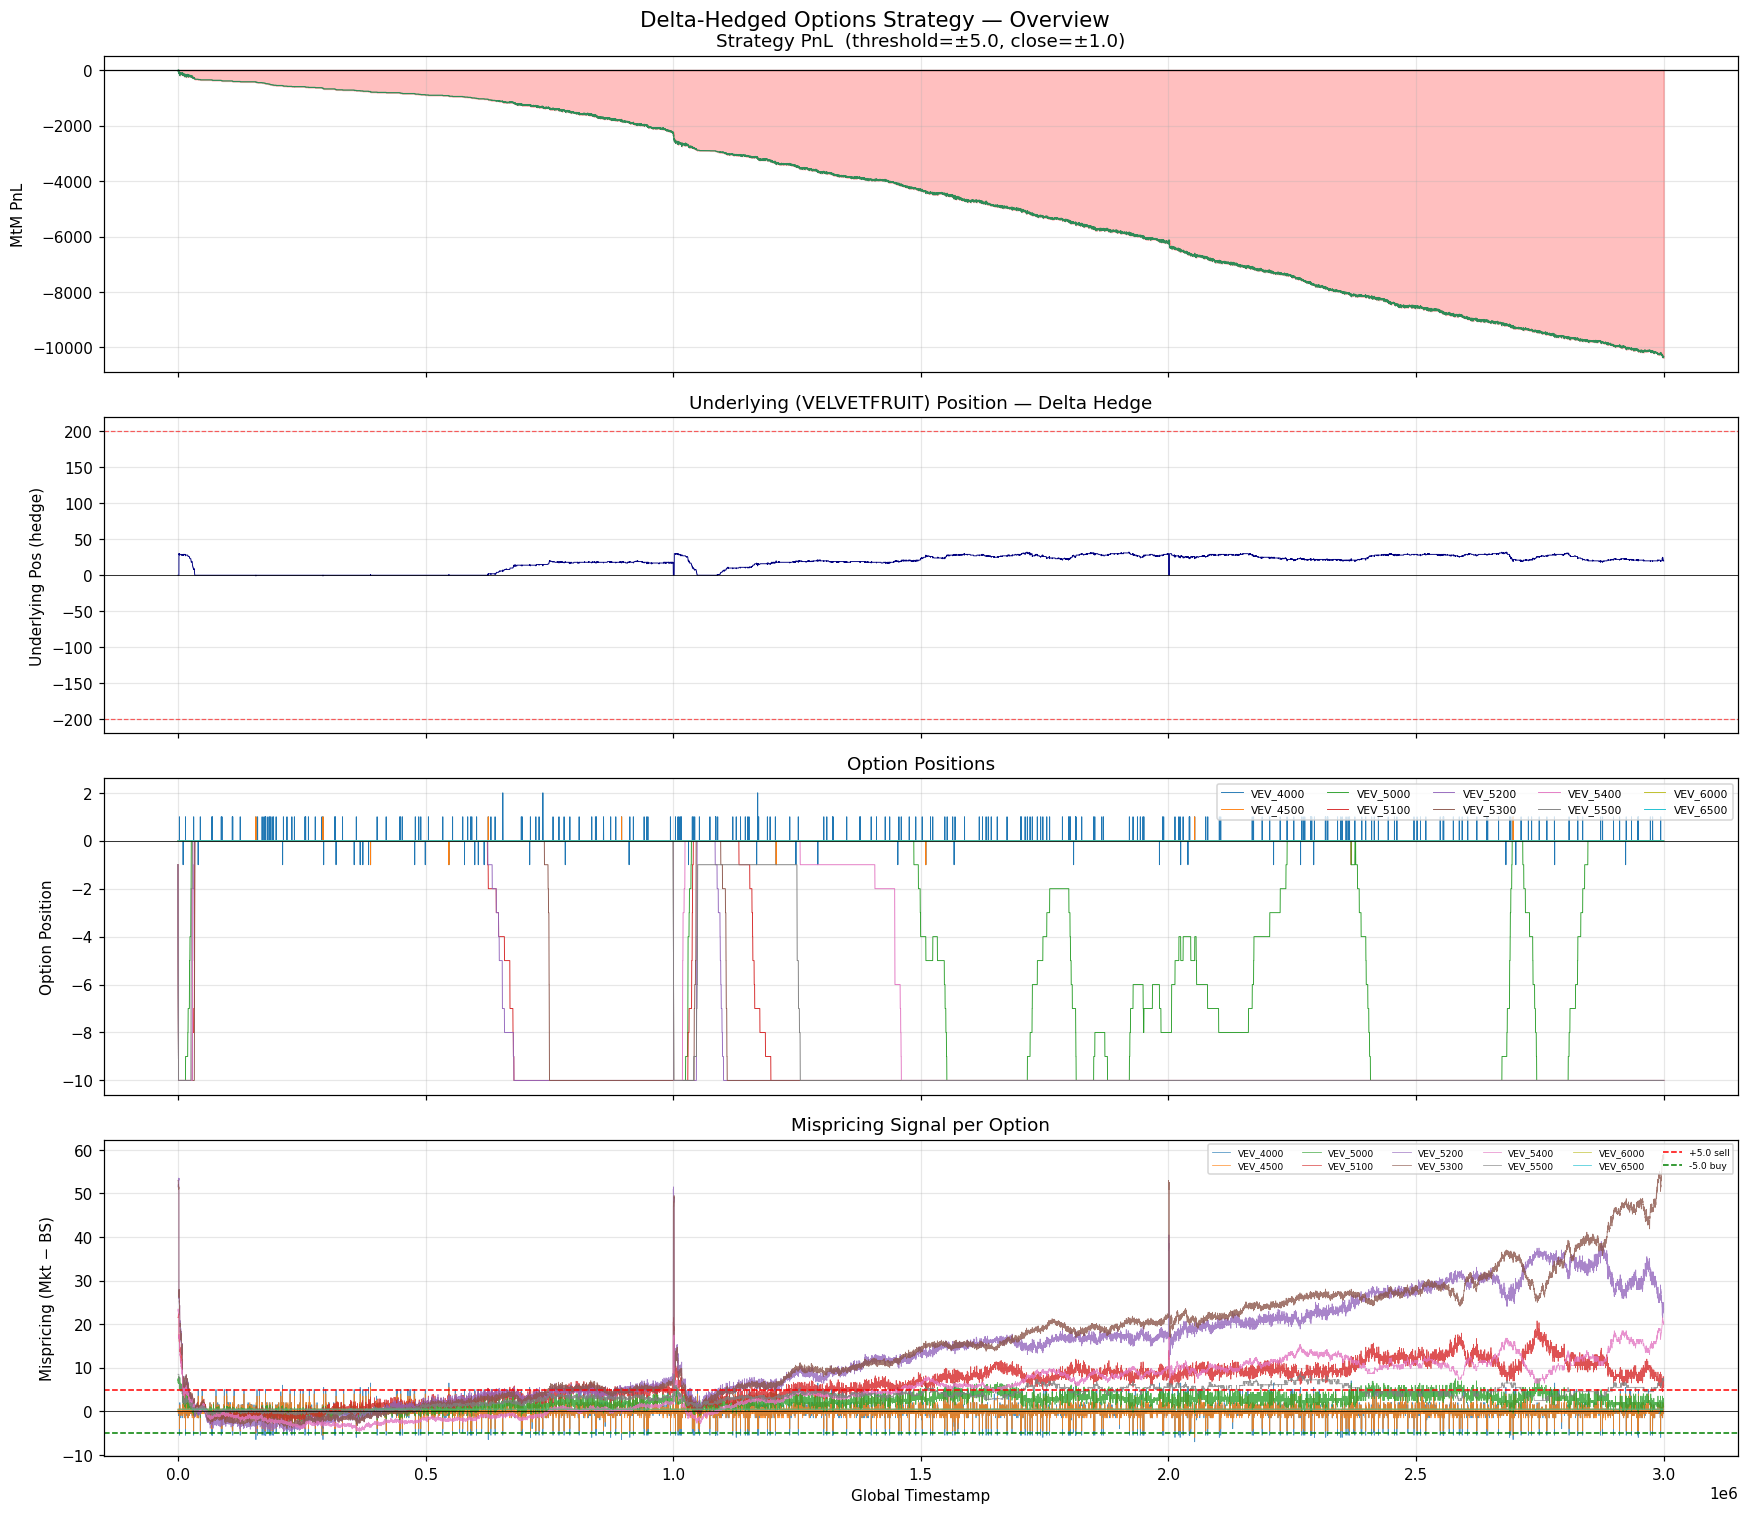

In [28]:

# ── Results: PnL + Underlying Hedge + Mispricing signals ─────────────────
ts_arr = np.array(ts_hist)

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)

# PnL
axes[0].plot(ts_arr, pnl_hist, linewidth=0.8, color='seagreen')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].fill_between(ts_arr, 0, pnl_hist,
                     where=np.array(pnl_hist) > 0, alpha=0.25, color='green')
axes[0].fill_between(ts_arr, 0, pnl_hist,
                     where=np.array(pnl_hist) < 0, alpha=0.25, color='red')
axes[0].set_ylabel('MtM PnL'); axes[0].grid(alpha=0.3)
axes[0].set_title(f'Strategy PnL  (threshold=±{MISPRICE_THRESHOLD}, close=±{CLOSE_THRESHOLD})')

# Underlying hedge position
axes[1].plot(ts_arr, und_pos_hist, linewidth=0.6, color='navy')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].axhline( UND_LIMIT, color='red',   linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].axhline(-UND_LIMIT, color='red',   linewidth=0.8, linestyle='--', alpha=0.6)
axes[1].set_ylabel('Underlying Pos (hedge)'); axes[1].grid(alpha=0.3)
axes[1].set_title('Underlying (VELVETFRUIT) Position — Delta Hedge')

# Option positions
cmap = cm.get_cmap('tab10', len(OPTION_PRODUCTS))
for i, p in enumerate(OPTION_PRODUCTS):
    axes[2].plot(ts_arr, opt_pos_hist[p], linewidth=0.6, color=cmap(i), label=p)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('Option Position'); axes[2].grid(alpha=0.3)
axes[2].legend(ncol=5, fontsize=7, loc='upper right')
axes[2].set_title('Option Positions')

# Mispricing per option
for i, p in enumerate(OPTION_PRODUCTS):
    mp = np.array(misprice_hist[p], dtype=float)
    axes[3].plot(ts_arr, mp, linewidth=0.5, color=cmap(i), label=p, alpha=0.8)
axes[3].axhline( MISPRICE_THRESHOLD, color='red',   linewidth=1, linestyle='--', label=f'+{MISPRICE_THRESHOLD} sell')
axes[3].axhline(-MISPRICE_THRESHOLD, color='green', linewidth=1, linestyle='--', label=f'-{MISPRICE_THRESHOLD} buy')
axes[3].axhline(0, color='black', linewidth=0.5)
axes[3].set_ylabel('Mispricing (Mkt − BS)'); axes[3].set_xlabel('Global Timestamp')
axes[3].grid(alpha=0.3); axes[3].legend(ncol=6, fontsize=6, loc='upper right')
axes[3].set_title('Mispricing Signal per Option')

plt.suptitle('Delta-Hedged Options Strategy — Overview', fontsize=14)
plt.tight_layout(); plt.show()


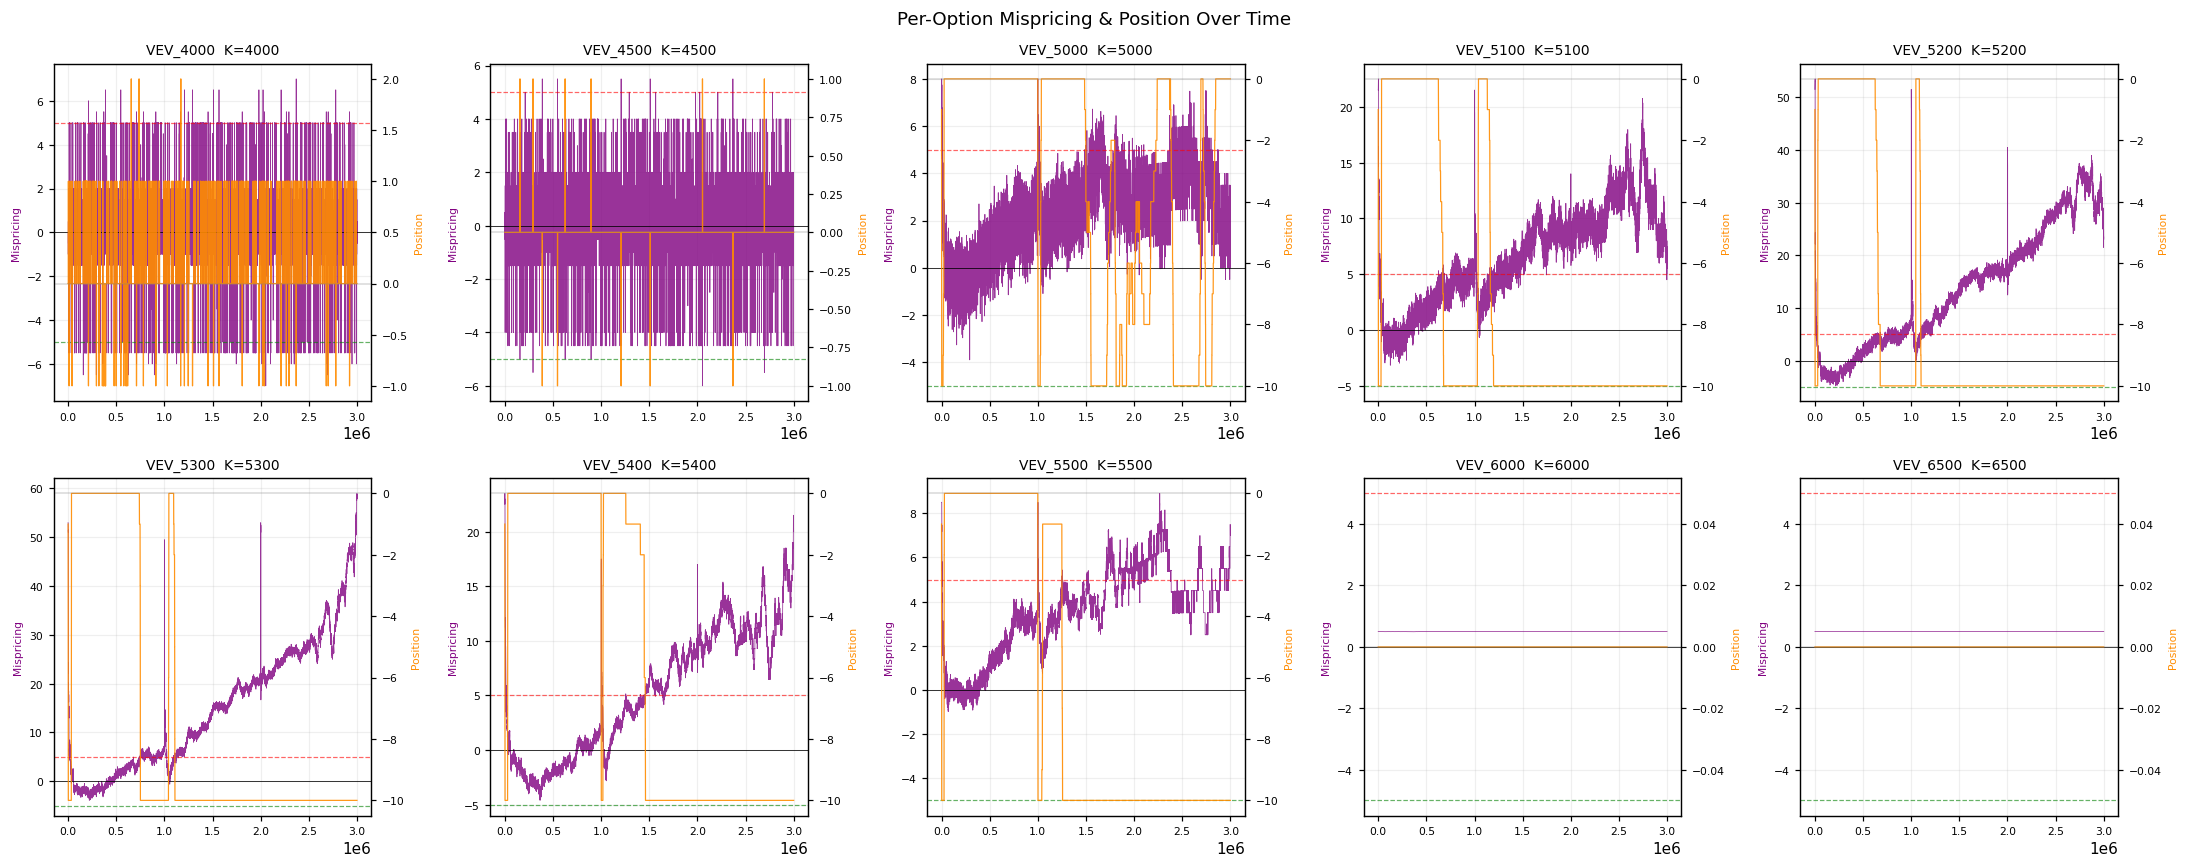

In [29]:

# ── Per-option PnL attribution ────────────────────────────────────────────
# Reconstruct each option's standalone P&L contribution
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K = STRIKES[product]
    mp = np.array(misprice_hist[product], dtype=float)
    pos = np.array(opt_pos_hist[product], dtype=float)
    bs = np.array(bs_price_hist[product], dtype=float)

    ax2 = ax.twinx()
    ax.plot(ts_arr, mp,  linewidth=0.5, color='purple', alpha=0.8, label='Mispricing')
    ax.axhline( MISPRICE_THRESHOLD, color='red',   linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axhline(-MISPRICE_THRESHOLD, color='green', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.axhline(0, color='black', linewidth=0.5)
    ax2.plot(ts_arr, pos, linewidth=0.8, color='darkorange', alpha=0.9, label='Position')
    ax2.axhline(0, color='gray', linewidth=0.3)

    ax.set_title(f'{product}  K={K}', fontsize=9)
    ax.set_ylabel('Mispricing', fontsize=7, color='purple')
    ax2.set_ylabel('Position', fontsize=7, color='darkorange')
    ax.tick_params(labelsize=7)
    ax2.tick_params(labelsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('Per-Option Mispricing & Position Over Time', fontsize=12)
plt.tight_layout(); plt.show()


In [30]:

# ── Strategy summary statistics ───────────────────────────────────────────
pnl_arr  = np.array(pnl_hist, dtype=float)
pnl_diff = np.diff(pnl_arr)
pnl_diff = pnl_diff[np.isfinite(pnl_diff)]

sharpe   = pnl_diff.mean() / pnl_diff.std() if pnl_diff.std() > 0 else np.nan
max_dd   = (pnl_arr - np.maximum.accumulate(np.where(np.isfinite(pnl_arr), pnl_arr, 0))).min()

print('=' * 60)
print('DELTA-HEDGED OPTIONS STRATEGY — SUMMARY')
print('=' * 60)
print(f"\nParameters:")
print(f"  Open threshold:   ±{MISPRICE_THRESHOLD}")
print(f"  Close threshold:  ±{CLOSE_THRESHOLD}")
print(f"  Max pos/option:   {MAX_OPT_POS}")
print(f"  Lot size:         {OPT_LOT}")
print(f"  Vol window:       {VOL_WINDOW_BT} ticks")

print(f"\nPerformance:")
print(f"  Final PnL:        {pnl_arr[-1]:>12,.2f}")
print(f"  Sharpe (per-tick):{sharpe:>12.4f}")
print(f"  Max drawdown:     {max_dd:>12,.2f}")

print(f"\nActivity per option:")
print(f"{'Option':<12} {'K':>6} {'Trades':>8} {'Max pos':>8} {'Avg misprice':>14}")
print('-' * 52)
for product in OPTION_PRODUCTS:
    K       = STRIKES[product]
    pos_arr = np.array(opt_pos_hist[product])
    mp_arr  = np.array(misprice_hist[product], dtype=float)
    n_trades = int(np.abs(np.diff(pos_arr)).sum())
    max_pos  = int(np.abs(pos_arr).max())
    avg_mp   = np.nanmean(np.abs(mp_arr))
    print(f"{product:<12} {K:>6} {n_trades:>8} {max_pos:>8} {avg_mp:>14.3f}")

print(f"\nDelta hedge:")
und_arr = np.array(und_pos_hist)
print(f"  Max long:         {und_arr.max():>6}")
print(f"  Max short:        {und_arr.min():>6}")
print(f"  Ticks at limit:   {(np.abs(und_arr) >= UND_LIMIT).sum():>6}")
print(f"  Hedge rebalances: {int(np.abs(np.diff(und_arr)).sum()):>6}")


DELTA-HEDGED OPTIONS STRATEGY — SUMMARY

Parameters:
  Open threshold:   ±5.0
  Close threshold:  ±1.0
  Max pos/option:   10
  Lot size:         1
  Vol window:       2000 ticks

Performance:
  Final PnL:          -10,333.00
  Sharpe (per-tick):     -0.0232
  Max drawdown:       -10,365.00

Activity per option:
Option            K   Trades  Max pos   Avg misprice
----------------------------------------------------
VEV_4000       4000      590        2          0.252
VEV_4500       4500       22        1          0.423
VEV_5000       5000      143       10          2.339
VEV_5100       5100       49       10          6.560
VEV_5200       5200       49       10         14.063
VEV_5300       5300       49       10         15.404
VEV_5400       5400       49       10          6.253
VEV_5500       5500       47       10          3.566
VEV_6000       6000        0        0          0.499
VEV_6500       6500        0        0          0.500

Delta hedge:
  Max long:             32
  Max sho

## 13. Bid-Ask Spread Analysis

In [31]:
# Build spread dataframe: one row per (global_ts, product)
spread_frames = []
for product in OPTION_PRODUCTS:
    sub = raw[raw['product'] == product][
        ['global_ts', 'day', 'timestamp', 'bid_price_1', 'ask_price_1']
    ].copy()
    sub['spread']  = sub['ask_price_1'] - sub['bid_price_1']
    sub['product'] = product
    sub['K']       = STRIKES[product]
    spread_frames.append(sub)

spreads = pd.concat(spread_frames, ignore_index=True)

print("Spread summary per option:")
print(
    spreads.groupby('product')['spread']
    .agg(['mean', 'median', 'std', 'min', 'max'])
    .round(3)
    .to_string()
)

Spread summary per option:
            mean  median    std  min  max
product                                  
VEV_4000  20.813    21.0  1.482    9   22
VEV_4500  15.853    16.0  1.189    7   17
VEV_5000   6.043     6.0  0.646    2    7
VEV_5100   4.296     4.0  0.580    1    6
VEV_5200   2.888     3.0  0.443    1    4
VEV_5300   2.107     2.0  0.390    1    3
VEV_5400   1.381     1.0  0.486    1    2
VEV_5500   1.150     1.0  0.357    1    2
VEV_6000   1.000     1.0  0.000    1    1
VEV_6500   1.000     1.0  0.000    1    1


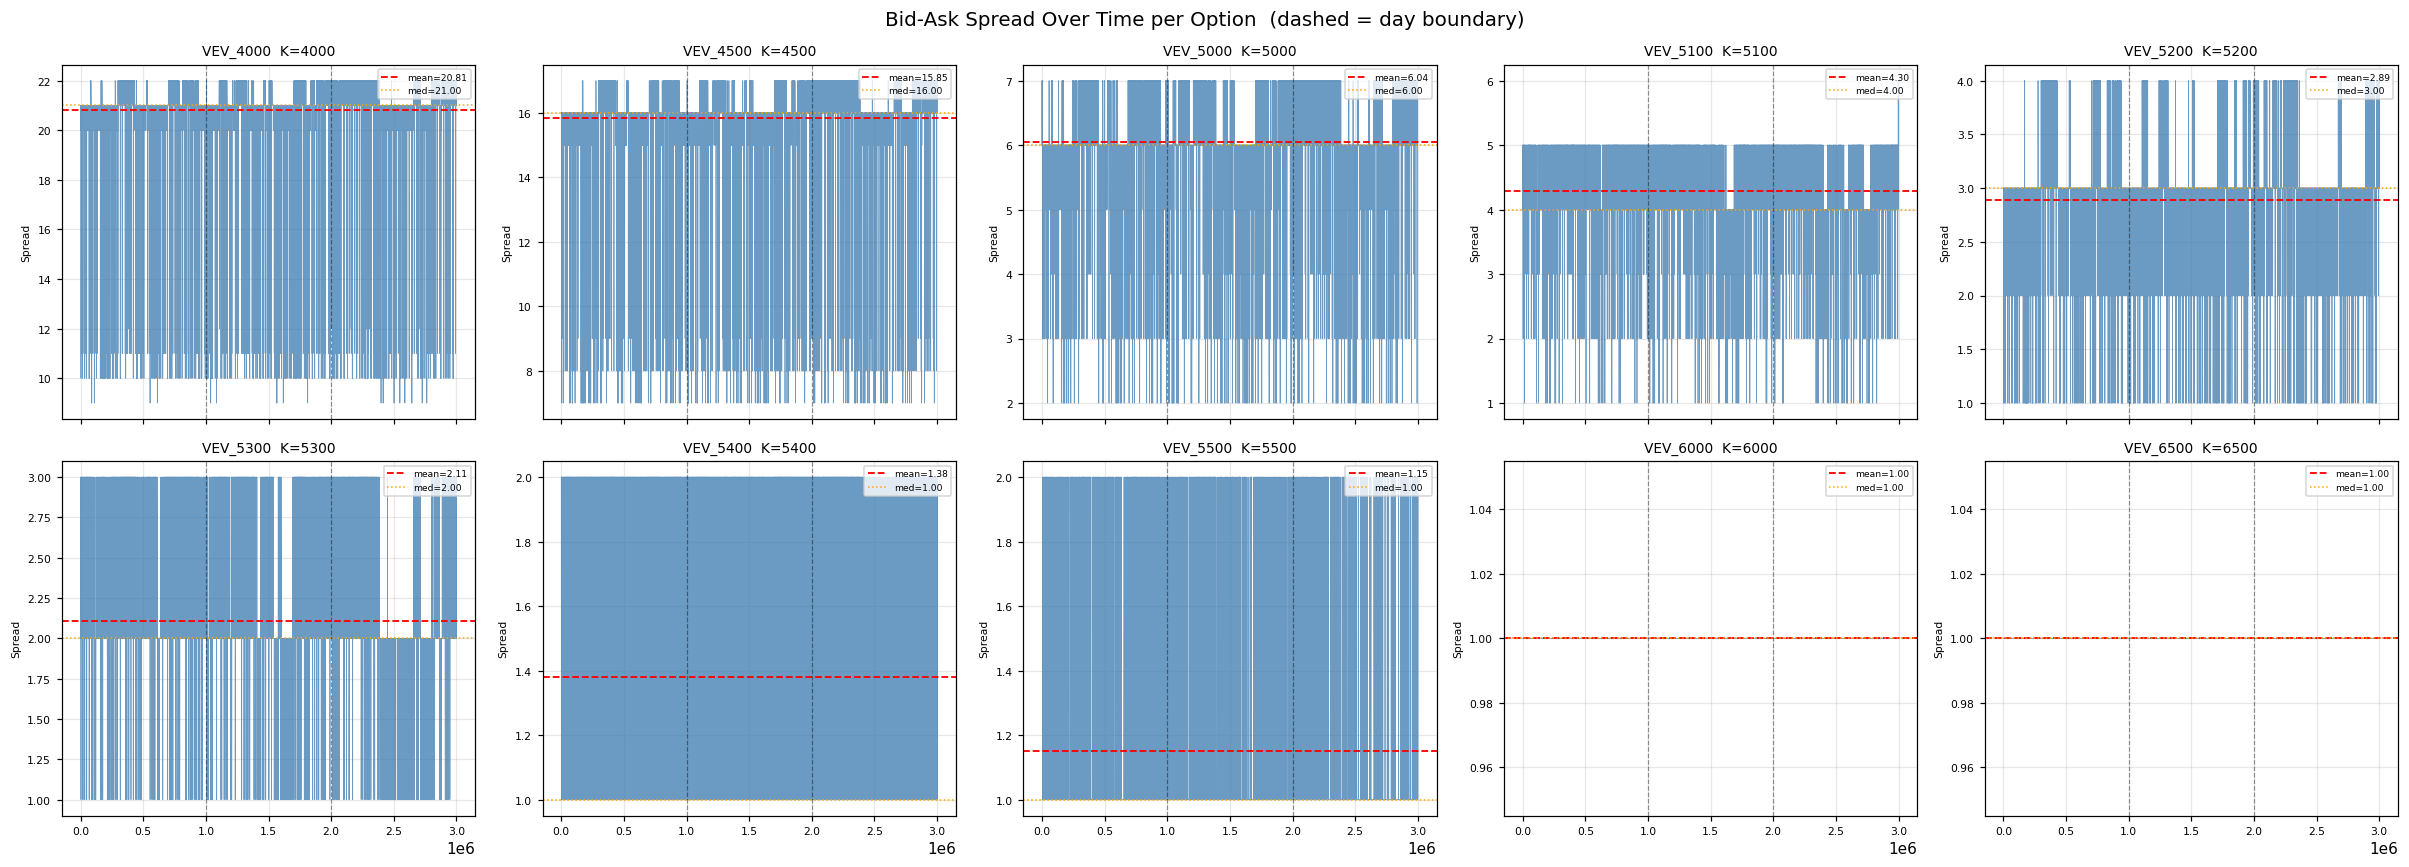

In [32]:
# ── Plot 1: Spread over time, one subplot per option ─────────────────────
cmap = cm.get_cmap('coolwarm', len(OPTION_PRODUCTS))

fig, axes = plt.subplots(2, 5, figsize=(22, 8), sharex=True)
axes = axes.flat

for ax, product in zip(axes, OPTION_PRODUCTS):
    K   = STRIKES[product]
    sub = spreads[spreads['product'] == product].sort_values('global_ts')
    ax.plot(sub['global_ts'], sub['spread'], linewidth=0.5, color='steelblue', alpha=0.8)
    ax.axhline(sub['spread'].mean(),   color='red',    linewidth=1.2, linestyle='--',
               label=f"mean={sub['spread'].mean():.2f}")
    ax.axhline(sub['spread'].median(), color='orange', linewidth=1.0, linestyle=':',
               label=f"med={sub['spread'].median():.2f}")
    # Day boundary lines
    for day in [1, 2]:
        ax.axvline(day * 1_000_000, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_title(f'{product}  K={K}', fontsize=9)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)
    ax.set_ylabel('Spread', fontsize=7)

plt.suptitle('Bid-Ask Spread Over Time per Option  (dashed = day boundary)', fontsize=13)
plt.tight_layout()
plt.show()

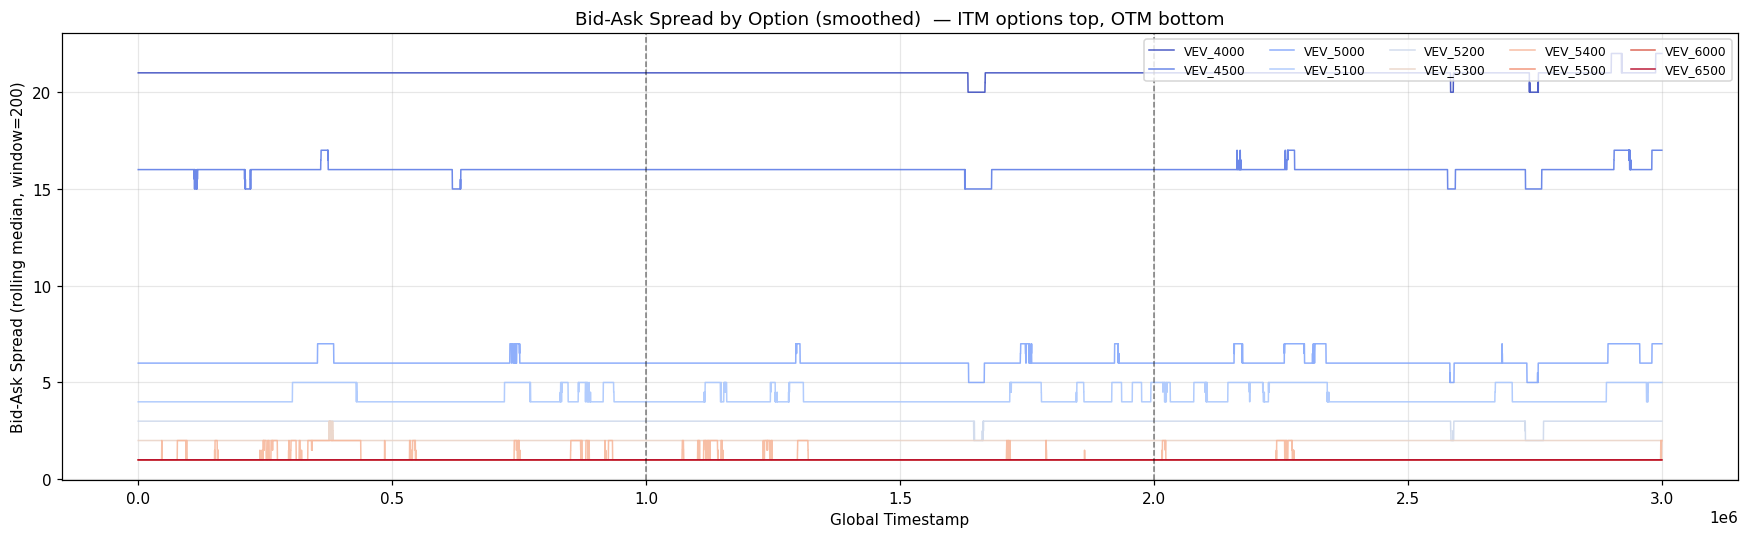

In [33]:
# ── Plot 2: All options on one chart (colored by strike) ─────────────────
fig, ax = plt.subplots(figsize=(16, 5))
cmap = cm.get_cmap('coolwarm', len(OPTION_PRODUCTS))

for i, product in enumerate(OPTION_PRODUCTS):
    sub = spreads[spreads['product'] == product].sort_values('global_ts')
    # Smooth with a rolling median for readability
    smoothed = sub['spread'].rolling(200, min_periods=1, center=True).median()
    ax.plot(sub['global_ts'], smoothed, linewidth=1.0, color=cmap(i), label=product, alpha=0.9)

for day in [1, 2]:
    ax.axvline(day * 1_000_000, color='black', linewidth=1.0, linestyle='--', alpha=0.5)

ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Bid-Ask Spread (rolling median, window=200)')
ax.set_title('Bid-Ask Spread by Option (smoothed)  — ITM options top, OTM bottom')
ax.legend(ncol=5, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

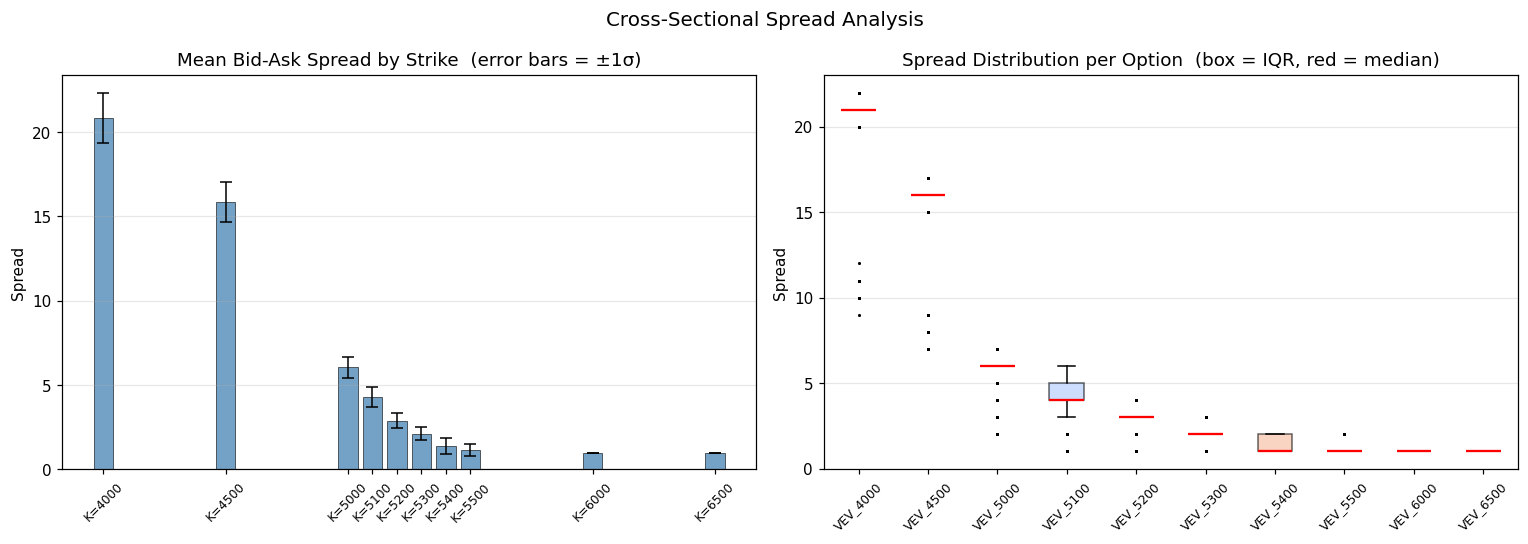

In [34]:
# ── Plot 3: Cross-sectional spread vs strike (mean ± std) ────────────────
spread_by_strike = (
    spreads.groupby('K')['spread']
    .agg(['mean', 'std', 'median'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar: mean spread per strike
axes[0].bar(spread_by_strike['K'], spread_by_strike['mean'],
            width=80, color='steelblue', alpha=0.75, edgecolor='black', linewidth=0.5,
            label='Mean spread')
axes[0].errorbar(spread_by_strike['K'], spread_by_strike['mean'],
                 yerr=spread_by_strike['std'],
                 fmt='none', color='black', capsize=4, linewidth=1)
axes[0].set_xticks(spread_by_strike['K'])
axes[0].set_xticklabels([f'K={k}' for k in spread_by_strike['K']], rotation=45, fontsize=8)
axes[0].set_ylabel('Spread')
axes[0].set_title('Mean Bid-Ask Spread by Strike  (error bars = ±1σ)')
axes[0].grid(axis='y', alpha=0.3)

# Spread distribution as box-plot per option
data_per_opt = [spreads[spreads['product'] == p]['spread'].values for p in OPTION_PRODUCTS]
bp = axes[1].boxplot(data_per_opt, labels=OPTION_PRODUCTS, patch_artist=True,
                     medianprops=dict(color='red', linewidth=1.5),
                     flierprops=dict(marker='.', markersize=1, alpha=0.3))
cmap = cm.get_cmap('coolwarm', len(OPTION_PRODUCTS))
for patch, color in zip(bp['boxes'], [cmap(i) for i in range(len(OPTION_PRODUCTS))]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_xticklabels(OPTION_PRODUCTS, rotation=45, fontsize=8)
axes[1].set_ylabel('Spread')
axes[1].set_title('Spread Distribution per Option  (box = IQR, red = median)')
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Sectional Spread Analysis', fontsize=13)
plt.tight_layout()
plt.show()

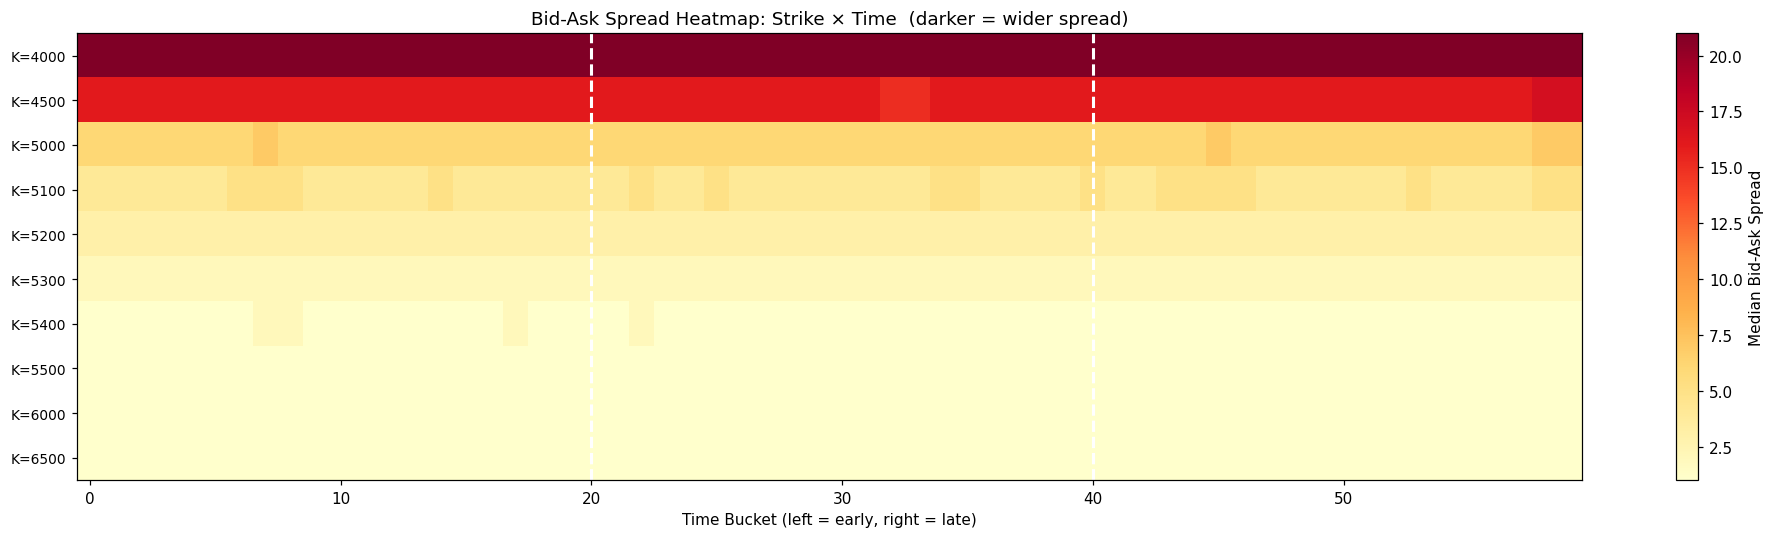


Spread as % of mid price (mean):
product
VEV_4000      1.66
VEV_4500      2.11
VEV_5000      2.37
VEV_5100      2.58
VEV_5200      3.03
VEV_5300      4.55
VEV_5400      9.00
VEV_5500     18.59
VEV_6000    200.00
VEV_6500    200.00


In [35]:
# ── Plot 4: Spread heatmap — strike × time ────────────────────────────────
spreads['ts_bin'] = pd.cut(spreads['global_ts'], bins=60, labels=False)
heat_spread = spreads.pivot_table(index='K', columns='ts_bin', values='spread', aggfunc='median')

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(heat_spread.values, aspect='auto', cmap='YlOrRd',
               interpolation='nearest')
plt.colorbar(im, ax=ax, label='Median Bid-Ask Spread')
ax.set_yticks(range(len(heat_spread.index)))
ax.set_yticklabels([f'K={k}' for k in heat_spread.index], fontsize=9)
ax.set_xlabel('Time Bucket (left = early, right = late)')
ax.set_title('Bid-Ask Spread Heatmap: Strike × Time  (darker = wider spread)')
for day_frac in [1/3, 2/3]:
    ax.axvline(day_frac * 60, color='white', linewidth=2, linestyle='--')
plt.tight_layout()
plt.show()

# ── Spread as fraction of mid price ──────────────────────────────────────
spreads_with_mid = spreads.merge(
    opts[['global_ts', 'product', 'C']].rename(columns={'C': 'mid'}),
    on=['global_ts', 'product'], how='left'
)
spreads_with_mid['spread_bps'] = spreads_with_mid['spread'] / spreads_with_mid['mid'].replace(0, np.nan) * 100

print("\nSpread as % of mid price (mean):")
print(
    spreads_with_mid.groupby('product')['spread_bps']
    .mean()
    .round(2)
    .rename('spread_%_of_mid')
    .to_string()
)